# Neuron-Level Causal Validation of Modality Competition — RML (v3)

Implements `experiment_protocol[From Prof KC Lan].docx` end to end. Section numbering follows that protocol's **Day 0 / Week 1–4** schedule, not the older "Phase A–E" labels.

**Restart rationale:** v1 and v2 evaluated the correct, SHA-verified RML checkpoints against a fabricated `meta.pkl` that does not exist in the source data archive. All prior numbers are retracted. See `docs/adr/0004-v3-restart-data-provenance-and-fidelity-gate.md`, `docs/adr/0005-day0-dominant-modality-recompute-and-fast-path.md`, and `journals/2026-08-09.md`.

**What is different in v3:**

| | |
|---|---|
| **Canonical data** | `BIG_DATA_RAW_PROCESSED_FACE` + `meta_one_hot_label_six_categories.pkl` filtered to the RML split files — the same source `main.py` used to train and evaluate every dataset in the thesis. The retired `RML_RAW_PROCESSED_Face` folder is never touched. |
| **Halting gates, not warnings** | Every check below `assert`s. Nothing prints a warning and continues. There is **no label-permutation solver** — the label order is the fixed constant from `getEmotionDict()`. |
| **Day 0 integrity gate** | Replicates `sample_imgs_by_interval` and confirms every constructed frame path exists, before any model runs. |
| **Day 0 fidelity gate** | Both checkpoints must reproduce 76.39% / 79.86% test accuracy (from the original training logs, now in `docs/provenance/`) within 1pp, or nothing downstream runs. |
| **Day 0 dominant modality** | Recomputed from the DeepSHAP pickles rather than inherited, and cross-checked in Week 1 against the activations actually extracted. |
| **Falsification pair** | A full-64 knockout and a random-5 control run *before* any real sweep, plus a threshold-free mechanical proof that the ablation hook writes through. |
| **Exact fast path** | Weeks 2–3 replay the model's linear head over cached activations instead of re-reading the dataset ~100 times, after proving it reproduces real forward passes exactly. |

**Run order:** top to bottom on a Colab GPU runtime. Do not skip a gate. If a cell halts, read its message — every `HALT` says what to check and what not to assume.

# Day 0 — Environment & Path Setup

In [1]:
# -- Torch/Torchaudio/Torchvision ABI self-check & auto-repair (Colab) --
# Colab's preinstalled torch/torchaudio/torchvision trio can drift out of sync
# across runtime image updates (mismatched AOTInductor ABI -> `undefined symbol:
# aoti_torch_abi_version` on `import torchaudio`). Rather than pin exact versions
# here (old pins may lack wheels for Colab's current Python), this cell verifies
# the trio actually imports together and, if not, reinstalls a mutually
# compatible set from PyPI and force-restarts the runtime once.
#
# Re-run this cell (and then all cells below) after any Colab runtime restart.
# See journals/2026-08-09.md for the incident this guards against.
import os
import subprocess
import sys

def _torch_stack_ok():
    try:
        import torch, torchaudio, torchvision  # noqa: F401
        return True
    except Exception as e:
        print(f"Torch stack import failed ({e!r}); reinstalling a matched trio.")
        return False

if not _torch_stack_ok():
    subprocess.run(
        [sys.executable, "-m", "pip", "uninstall", "-y", "-q", "torch", "torchaudio", "torchvision"],
        check=True,
    )
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "torch", "torchaudio", "torchvision"],
        check=True,
    )
    print("Reinstalled matched torch/torchaudio/torchvision.", flush=True)
    print("RESTARTING RUNTIME NOW -- Colab reconnects on its own. When it does, "
          "re-run this notebook from cell 1.", flush=True)
    # Without an actual process kill the stale, already-imported torch stays
    # resident and every cell below fails with the same ABI error the reinstall
    # just fixed. The old version of this cell only printed "Restarting..." and
    # kept going, which is how that failure looked like a fix that didn't work.
    os.kill(os.getpid(), 9)

# -- transformers pin (Colab's default drifts across images; ALBERT forward
# pass breaks silently -- no exception, just wrong numbers -- on newer majors.
# See journals/2026-08-11.md, Day 0 Fidelity Gate halt.) --
def _transformers_pinned():
    try:
        import transformers
        return transformers.__version__ == "4.38.2"
    except Exception:
        return False

if not _transformers_pinned():
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "transformers==4.38.2"],
        check=True,
    )
    print("Installed pinned transformers==4.38.2 (was drifting on Colab's default).", flush=True)

In [2]:
# -- Global Environment & Path Setup --
import os
import sys
import random
import hashlib
import types
import builtins
import math
import numpy as np
import torch
import torch.nn as nn

builtins.torch = torch
builtins.nn = nn

# Defensive compatibility shims for transformers/torch API drift.
# These only patch missing attributes so transformers' import checks don't
# crash against whatever torch build the auto-repair cell above installed;
# they do not change any numerical behavior of the model itself.
if not hasattr(torch, 'get_default_device'):
    torch.get_default_device = lambda: torch.device("cpu")
if not hasattr(torch, 'set_default_device'):
    torch.set_default_device = lambda dev: None
if not hasattr(torch, 'is_compiling'):
    torch.is_compiling = lambda: False
if not hasattr(torch, 'compiler'):
    comp_mod = types.ModuleType('compiler')
    comp_mod.is_compiling = lambda: False
    torch.compiler = comp_mod

import transformers
import transformers.utils.import_utils as import_utils
import_utils.BACKENDS_MAPPING["torch"] = (lambda: True, "PyTorch library")
import_utils.is_torch_available = lambda: True
import_utils._torch_available = True
if hasattr(transformers, 'is_torch_available'):
    transformers.is_torch_available = lambda: True
try:
    from transformers.models.albert.modeling_albert import AlbertModel as RealAlbertModel
    transformers.AlbertModel = RealAlbertModel
    sys.modules['transformers'].AlbertModel = RealAlbertModel
except Exception as e:
    print(f"Notice on AlbertModel binding: {e}")

import subprocess

def _ensure_installed(module_name, pip_name):
    try:
        __import__(module_name)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pip_name], check=True)

_ensure_installed("facenet_pytorch", "facenet-pytorch")
# AlbertTokenizer (slow, SentencePiece-backed) needs `sentencepiece`, which is
# not always preinstalled on Colab -- same drift risk as torch/torchaudio above.
_ensure_installed("sentencepiece", "sentencepiece")

def set_deterministic_seed(seed: int = 0) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_deterministic_seed(0)

# -- Path resolution & Google Drive mount --
project_path = None
try:
    from google.colab import drive
    if not os.path.exists('/content/drive/MyDrive'):
        drive.mount('/content/drive', force_remount=False)
except Exception:
    pass

for candidate in ['/content/drive/MyDrive/multimodal-causal-ablation',
                  '/content/multimodal-causal-ablation',
                  os.getcwd()]:
    if os.path.exists(candidate) and os.path.exists(os.path.join(candidate, 'checkpoints')):
        project_path = candidate
        break
if project_path is None:
    project_path = os.getcwd()

os.chdir(project_path)
if project_path not in sys.path:
    sys.path.insert(0, project_path)
model_src = os.path.join(project_path, 'Model/Dig-Data_Model-Main')
if model_src not in sys.path:
    sys.path.insert(0, model_src)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Working directory: {os.getcwd()}")
print(f"Runtime device: {device}")

# -- Fixed constants (do not fit these to data; see ADR 0004) --
# Label ordering is the training-time constant from Model/Dig-Data_Model-Main/src/datasets.py::getEmotionDict().
# There is no label-permutation solver in this notebook.
EMO_DICT = {'ang': 0, 'dis': 1, 'fea': 2, 'hap': 3, 'sad': 4, 'sur': 5}
EMOTION_CLASSES = ['anger', 'disgust', 'fear', 'happiness', 'sadness', 'surprise']
RAW_EMO_KEYS = ['ang', 'dis', 'fea', 'hap', 'sad', 'sur']

# MODEL_ARGS confirmed against the exact training command lines, now copied into
# docs/provenance/RML_{origin,finetune}_training_log.txt (line 1 of each):
#   origin:   -lr=1e-5 -wd=1e-3 -ep=40 -mod=tav -bs=4 --img-interval=500 --early-stop=6  --loss=ce
#   finetune: -lr=5e-5         -ep=40 -mod=tav -bs=4 --img-interval=500 --early-stop=40 --loss=ce
#   both:     --model=mme2e --num-emotions=6 --trans-dim=64 --trans-nlayers=4
#             --trans-nheads=4 --text-lr-factor=10 --text-model-size=large --text-max-len=100
# The two runs differ only in optimizer/schedule settings, which are irrelevant at
# inference. Every ARCHITECTURE argument below is identical across both, so one
# MODEL_ARGS correctly instantiates both checkpoints. (An earlier version of this
# comment quoted only the finetune line -- a documentation gap, never a behavior bug.)
MODEL_ARGS = {
    'num_emotions': 6,
    'modalities': 'tav',
    'feature_dim': 256,
    'trans_nlayers': 4,
    'trans_nheads': 4,
    'trans_dim': 64,
    'text_model_size': 'large',
    'text_max_len': 100,
}

# Canonical label/text source (ADR 0004): the merged-corpus meta. Its keys are the
# same ID namespace as the split files ('s3_f3per_ha2') and its labels are already
# one-hot. Do NOT substitute the small meta.pkl that ships inside
# RML_RAW_PROCESSED_Face.tar.gz -- that one is genuine but uses the 's1_an1'
# namespace with string labels, so it cannot be joined to the split files.
DATA_DIR = os.path.join(project_path, 'Model/Dig-Data_Model-Main/data')
META_PATH = os.path.join(DATA_DIR, 'BIG_DATA_RAW_PROCESSED_FACE',
                         'meta_one_hot_label_six_categories.pkl')
SPLIT_DIR = os.path.join(DATA_DIR, 'data_split', 'all_single_label_six_category', 'with_valid')

# The 720 utterance folders are NOT read over the Drive mount (see the extraction
# cell below for why). MAIN_FOLDER is assigned there, to a runtime-local path.
MAIN_FOLDER = None
RML_TAR_PATH = os.path.join(project_path, 'data_bundle', 'RML_RAW_PROCESSED_Face.tar.gz')
RML_TAR_BYTES = 592913715
RML_TAR_SHA256 = '2881def332853eee24e10fe338512155c86b307aa9cb4b5fd16097a1c61b5ae2'

# The audio the training run actually read. RML_RAW_PROCESSED_Face.tar.gz carries
# only `audio.wav` (stereo, 44100 Hz), but the training-era loader --
# `code/Noisy label/O2U-Net-master/data/datasets.py:392` on the handover drive --
# opens `audio_16000.wav`, and DIAGNOSTIC 6 showed no reconstruction of that file
# reproduces the fine-tuned model's logged accuracy. The real files were found
# inside BIG_DATA_RAW_PROCESSED_FACE.tar.gz (42 GB, handover drive); the 720 that
# belong to the RML splits were extracted and repacked here. Each is 16 kHz, mono,
# 32-bit float, i.e. already downmixed and resampled by whatever tool produced it.
# Provenance is sound: `audio.wav` for s6_f2urd_an9, s7_f3pjb_su2 and s7_f2urd_an7
# is md5-identical between the two archives, so they are the same recordings.
AUDIO16K_TAR_PATH = os.path.join(project_path, 'data_bundle', 'RML_audio16k_all720.tar')
AUDIO16K_TAR_BYTES = 231294464
AUDIO16K_TAR_SHA256 = 'b7c3c7f448a472c1afd2767bfac6306ddcaec8759d2f9a2741a29edcbe71cc06'

CHECKPOINTS_DIR = os.path.join(project_path, 'checkpoints')
BASE_CKPT = os.path.join(CHECKPOINTS_DIR, 'base_model.pt')
FT_CKPT = os.path.join(CHECKPOINTS_DIR, 'finetuned_model.pt')

for d in [os.path.join(CHECKPOINTS_DIR, 'activations'),
          os.path.join(project_path, 'results'),
          os.path.join(project_path, 'figures')]:
    os.makedirs(d, exist_ok=True)

def compute_sha256(filepath):
    if not os.path.exists(filepath):
        return "FILE_NOT_FOUND"
    hasher = hashlib.sha256()
    with open(filepath, 'rb') as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            hasher.update(chunk)
    return hasher.hexdigest()

print("Checkpoint SHA-256:")
print(f"  base_model.pt      {compute_sha256(BASE_CKPT)}")
print(f"  finetuned_model.pt {compute_sha256(FT_CKPT)}")
print("Expected (docs/adr/0004-...):")
print("  base_model.pt      565bc220d187f2286500481fdab4d3b3dc4f92a2006ffb8f02ca4c882bbd82db")
print("  finetuned_model.pt a4c1707f7bcc189d3103b42ea82c9d01f6ec2f992850e8cc1072f38f4dadd0de")
assert compute_sha256(BASE_CKPT) == "565bc220d187f2286500481fdab4d3b3dc4f92a2006ffb8f02ca4c882bbd82db", \
    "base_model.pt does not match the verified checkpoint. Stop and re-sync before continuing."
assert compute_sha256(FT_CKPT) == "a4c1707f7bcc189d3103b42ea82c9d01f6ec2f992850e8cc1072f38f4dadd0de", \
    "finetuned_model.pt does not match the verified checkpoint. Stop and re-sync before continuing."
print("Checkpoint identity verified.")

Working directory: /content/drive/MyDrive/multimodal-causal-ablation
Runtime device: cuda:0
Checkpoint SHA-256:
  base_model.pt      565bc220d187f2286500481fdab4d3b3dc4f92a2006ffb8f02ca4c882bbd82db
  finetuned_model.pt a4c1707f7bcc189d3103b42ea82c9d01f6ec2f992850e8cc1072f38f4dadd0de
Expected (docs/adr/0004-...):
  base_model.pt      565bc220d187f2286500481fdab4d3b3dc4f92a2006ffb8f02ca4c882bbd82db
  finetuned_model.pt a4c1707f7bcc189d3103b42ea82c9d01f6ec2f992850e8cc1072f38f4dadd0de
Checkpoint identity verified.


# Day 0 — Data Loading (Canonical Source) & Halting Fidelity Gate

Loads RML samples from `BIG_DATA_RAW_PROCESSED_FACE` + `meta_one_hot_label_six_categories.pkl`, filtered by the RML split files — mirroring `main.py::get_dataset_iemocap` exactly (same main folder, same meta file, same label dict). Evaluates both checkpoints on the 144-sample test split and **halts** if test accuracy doesn't reproduce the paper's published RML numbers.

In [3]:
# -- Day 0 step 0: materialize the RML corpus INSIDE the runtime --
#
# Why this cell exists (2026-08-11). The 720 utterance folders used to be read
# directly off the Google Drive mount. That failed: Drive had silently created
# conflict copies (`image_64 (1).jpg`, `image_135 (2).jpg`, ...) inside two
# folders. Those names still match `image_*.jpg`, so they inflate
# `nums = len(glob(folder/image_*.jpg))` in IEMOCAP.sample_imgs_by_interval and
# make it request frame indices that were never recorded. The Day 0 gate caught
# it, but the class of bug is unbounded: any future Drive hiccup re-introduces it.
#
# So the corpus now comes from an immutable archive, verified by SHA-256 and
# unpacked into the runtime's local disk. Nothing under the Drive mount is
# mutated, and the frame set the model sees is a property of the archive hash,
# not of Drive's current state.
#
# Archive provenance: handover drive,
#   data/Processed data/Database_processed_targz/RML_RAW_PROCESSED_Face.tar.gz
# Verified 2026-08-11 by streaming every member and MD5-comparing against the
# Drive-mount copy: 96,980 files present on both sides, 96,980 MD5 matches,
# 0 differing. The only Drive-side extras were the 42 conflict copies (all
# MD5-identical to their originals) and 658 `audio_16000.wav` files.
#
# Corrected 2026-08-12. This comment used to describe those `audio_16000.wav`
# files as files "which no code path reads." That was wrong, and it is the reason
# the fidelity gate failed: the training-era loader reads them, and reading
# `audio.wav` at 44100 Hz instead scores 56.94% against the logged 76.39%. The
# 720 files belonging to the RML splits are shipped as
# data_bundle/RML_audio16k_all720.tar and overlaid onto the extracted corpus at
# the end of this cell. See journals/2026-08-11-session1.md.
import glob
import shutil
import struct
import tarfile

RUNTIME_ROOT = '/content' if os.path.isdir('/content') else os.path.join(project_path, '.runtime_data')
os.makedirs(RUNTIME_ROOT, exist_ok=True)
RML_EXTRACT_DIR = os.path.join(RUNTIME_ROOT, 'rml_data')
MAIN_FOLDER = os.path.join(RML_EXTRACT_DIR, 'RML_RAW_PROCESSED_Face')

assert os.path.exists(RML_TAR_PATH), (
    f"RML archive not found at {RML_TAR_PATH}. It is staged from the handover drive into "
    "data_bundle/ (git-ignored, ~593 MB) and must finish uploading to Drive before this "
    "notebook can run on Colab."
)

_local_tar = os.path.join(RUNTIME_ROOT, 'RML_RAW_PROCESSED_Face.tar.gz')
if not os.path.exists(_local_tar) or os.path.getsize(_local_tar) != RML_TAR_BYTES:
    print(f"Copying archive from Drive to {RUNTIME_ROOT} ...")
    shutil.copyfile(RML_TAR_PATH, _local_tar)

# Verify the archive BEFORE extracting. A truncated Drive download is the most
# likely failure here and it would otherwise surface as missing frames.
_tar_bytes = os.path.getsize(_local_tar)
assert _tar_bytes == RML_TAR_BYTES, (
    f"HALT: archive is {_tar_bytes} bytes, expected {RML_TAR_BYTES}. Drive copy is truncated; "
    "delete it and re-run this cell."
)
_tar_sha = compute_sha256(_local_tar)
assert _tar_sha == RML_TAR_SHA256, (
    f"HALT: archive SHA-256 {_tar_sha} != expected {RML_TAR_SHA256}. The runtime copy is the "
    "right size but wrong content, so the re-copy guard above (which keys on size) will not "
    f"replace it: delete {_local_tar} and re-run this cell. If it still mismatches, the Drive "
    "copy itself is not the verified handover archive -- do not proceed."
)
print(f"Archive verified: {_tar_bytes} bytes, sha256 {_tar_sha[:16]}...")

_extract_stamp = os.path.join(RML_EXTRACT_DIR, '.extracted_' + RML_TAR_SHA256[:16])
if not os.path.exists(_extract_stamp):
    if os.path.isdir(RML_EXTRACT_DIR):
        shutil.rmtree(RML_EXTRACT_DIR)   # a half-finished previous extraction is worse than none
    os.makedirs(RML_EXTRACT_DIR, exist_ok=True)
    print("Extracting (106,731 members; takes a few minutes) ...")
    with tarfile.open(_local_tar, 'r:gz') as tf:
        tf.extractall(RML_EXTRACT_DIR)   # single pass; getmembers() first would cost a second one
    # The archive also carries ./RML_RAW_PROCESSED_Face/meta.pkl. It is a REAL file
    # (52,250 bytes, not fabricated -- ADR 0004 said otherwise and was wrong on that
    # point), but it is unusable here: its keys are a different ID namespace
    # ('s1_an1') than the split files ('s3_f3per_ha2'), and its labels are strings,
    # not the one-hot vectors this notebook consumes. Leaving it next to the
    # canonical meta invites exactly the mix-up ADR 0004 exists to prevent, so it is
    # deleted immediately after extraction; the assert below proves that worked.
    _archive_meta = os.path.join(MAIN_FOLDER, 'meta.pkl')
    if os.path.exists(_archive_meta):
        os.remove(_archive_meta)
    open(_extract_stamp, 'w').close()
    print("Extraction complete.")
else:
    print(f"Reusing existing extraction at {RML_EXTRACT_DIR}.")

assert os.path.isdir(MAIN_FOLDER), f"HALT: {MAIN_FOLDER} not present after extraction."
assert not os.path.exists(os.path.join(MAIN_FOLDER, 'meta.pkl')), (
    "HALT: the archive's own meta.pkl was extracted into MAIN_FOLDER. Wrong ID namespace; remove it."
)
# `tar -tzf` shows exactly 720 utterance directories. Asserting it here turns a
# disk-full or interrupted extraction into one clear failure, instead of hundreds
# of 'sample folder missing' entries from the integrity gate one cell later.
# Strip macOS AppleDouble sidecars (`._name`) left inside MAIN_FOLDER by an
# earlier run of this cell -- see the 16 kHz overlay below for where they come
# from. They carry only HFS metadata, so removing them cannot change a single
# sample the loader reads, and leaving them makes the count assert below fire on
# every re-run even though the extraction is perfectly good.
_stale_ad = (glob.glob(os.path.join(MAIN_FOLDER, '._*'))
             + glob.glob(os.path.join(MAIN_FOLDER, '*', '._*')))
for _p in _stale_ad:
    os.remove(_p)
if _stale_ad:
    print(f"Removed {len(_stale_ad)} AppleDouble sidecar files left by a previous run.")

_n_folders = len(os.listdir(MAIN_FOLDER))
assert _n_folders == 720, (
    f"HALT: {MAIN_FOLDER} holds {_n_folders} entries, expected 720 utterance folders. "
    f"The extraction is incomplete (check free disk space). Delete {RML_EXTRACT_DIR} and re-run."
)
# Overlay the training-era 16 kHz audio on top of the extracted corpus. The tar
# holds `<utterance id>/audio_16000.wav` for all 720 split IDs, so it unpacks
# straight into MAIN_FOLDER beside each folder's existing `audio.wav`.
# IEMOCAP.__getitem__ prefers `audio_16000.wav` when present and falls back to
# resampling `audio.wav` when it is not, so this overlay is what moves the run
# from "reconstructed audio" to "the bytes the training run read".
#
# Adding a second wav puts 111 members in each folder, which is what the training
# machine saw. That is why sample_imgs_by_interval counts `image_*.jpg` directly
# instead of the old `len(files) - 2`: the count then holds with or without this
# overlay, and the frame indices cannot silently shift.
assert os.path.exists(AUDIO16K_TAR_PATH), (
    f"HALT: {AUDIO16K_TAR_PATH} not found. Without it the audio branch falls back to "
    "resampling audio.wav, which reproduces the base model but leaves the fine-tuned "
    "model 1.39 pp low -- the fidelity gate will fail."
)
# Copy to runtime-local disk before hashing, exactly as the big archive above does.
# Hashing across the Drive mount is not safe: on 2026-08-12 a single read of this
# very file returned a digest of 48810957... while three later reads of the same
# unchanged bytes (same size, same mtime) all returned the correct
# b7c3c7f4.... A bad read here would HALT a good archive, which is
# indistinguishable in the moment from real corruption.
_a16_local = os.path.join(RUNTIME_ROOT, 'RML_audio16k_all720.tar')
if not os.path.exists(_a16_local) or os.path.getsize(_a16_local) != AUDIO16K_TAR_BYTES:
    print(f"Copying 16 kHz audio archive from Drive to {RUNTIME_ROOT} ...")
    shutil.copyfile(AUDIO16K_TAR_PATH, _a16_local)

_a16_bytes = os.path.getsize(_a16_local)
assert _a16_bytes == AUDIO16K_TAR_BYTES, (
    f"HALT: 16 kHz archive is {_a16_bytes} bytes, expected {AUDIO16K_TAR_BYTES}. The Drive "
    f"copy is truncated; delete {_a16_local} and re-run this cell."
)
_a16_sha = compute_sha256(_a16_local)
assert _a16_sha == AUDIO16K_TAR_SHA256, (
    f"HALT: 16 kHz archive SHA-256 {_a16_sha} != expected {AUDIO16K_TAR_SHA256}. Delete "
    f"{_a16_local} and re-run this cell (the size guard above will not replace it)."
)
# The archive was packed on macOS, so alongside its 1441 real members it carries
# 1441 AppleDouble sidecars: `._.`, `./._<id>` for every folder, and
# `./<id>/._audio_16000.wav` for every clip. macOS `tar -tf` folds them back into
# their parents and never lists them, which is why they went unnoticed when the
# archive was built; Python's tarfile on Linux materializes each one as a real
# file. That puts 721 junk entries at the top of MAIN_FOLDER -- enough to break
# the `_n_folders == 720` assert above on any re-run -- and one extra member in
# every utterance folder. Drop them here so they never land at all.
with tarfile.open(_a16_local, 'r:') as tf:
    _members = [m for m in tf.getmembers()
                if not os.path.basename(m.name).startswith('._')]
    assert len(_members) == 1441, (
        f"HALT: 16 kHz archive holds {len(_members)} non-AppleDouble members, expected 1441 "
        "(one archive root, 720 utterance directories, 720 audio_16000.wav files)."
    )
    tf.extractall(MAIN_FOLDER, members=_members)

_n_16k = len(glob.glob(os.path.join(MAIN_FOLDER, '*', 'audio_16000.wav')))
assert _n_16k == 720, (
    f"HALT: {_n_16k} of 720 audio_16000.wav files landed in MAIN_FOLDER. A partial overlay "
    "would silently mix training-era audio with resampled audio across the split."
)
# A file named audio_16000.wav that is not 16 kHz would reinstate the original bug
# without changing a single visible number, so check the header rather than the name.
# These are IEEE-float WAVs (format tag 3), which the stdlib `wave` module refuses,
# so read the fmt chunk directly.
def read_wav_fmt(path):
    """(format tag, channels, sample rate, bits) from a canonical WAV header."""
    with open(path, 'rb') as fh:
        head = fh.read(44)
    assert head[:4] == b'RIFF' and head[8:12] == b'WAVE', f'{path} is not a RIFF/WAVE file'
    tag, ch, rate, _byte_rate, _align, bits = struct.unpack('<HHIIHH', head[20:36])
    return tag, ch, rate, bits

_bad_rate = []
for _f in glob.glob(os.path.join(MAIN_FOLDER, '*', 'audio_16000.wav')):
    _tag, _ch, _rate, _bits = read_wav_fmt(_f)
    if _rate != 16000:
        _bad_rate.append((_f, _rate))
assert not _bad_rate, (
    f"HALT: {len(_bad_rate)} audio_16000.wav files are not 16 kHz, e.g. {_bad_rate[0]}."
)
print(f"16 kHz audio overlaid: {_n_16k} files, all 16000 Hz, {_ch} channel(s), "
      f"{_bits}-bit format tag {_tag}, sha256 {_a16_sha[:16]}...")

print(f"MAIN_FOLDER = {MAIN_FOLDER}  ({_n_folders} utterance folders)")
print(f"META_PATH   = {META_PATH}  (canonical one-hot labels, read from Drive)")


Archive verified: 592913715 bytes, sha256 2881def332853eee...
Reusing existing extraction at /content/rml_data.
Removed 1441 AppleDouble sidecar files left by a previous run.


/tmp/ipykernel_34664/537473693.py:166: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(MAIN_FOLDER, members=_members)


16 kHz audio overlaid: 720 files, all 16000 Hz, 1 channel(s), 32-bit format tag 3, sha256 b7c3c7f448a472c1...
MAIN_FOLDER = /content/rml_data/RML_RAW_PROCESSED_Face  (720 utterance folders)
META_PATH   = /content/drive/MyDrive/multimodal-causal-ablation/Model/Dig-Data_Model-Main/data/BIG_DATA_RAW_PROCESSED_FACE/meta_one_hot_label_six_categories.pkl  (canonical one-hot labels, read from Drive)


In [5]:
# -- Day 0: Canonical Data Load + Halting Fidelity Gate --
import glob
import json
import pickle
import re
import numpy as np
import torch
from torch.utils.data import DataLoader
import transformers
from transformers import AlbertTokenizer

try:
    from tqdm.notebook import tqdm
except Exception:
    from tqdm import tqdm

# The Drive-hosted src/datasets.py is the pre-audio-fix loader: it reads `audio.wav`
# at 44100 Hz with win_length = int(sr / 44100 * 400) and no resample, which is the
# 56.94% front end. The fixed file exists in the repo but the Google Drive desktop
# client has stopped uploading it, so Colab still sees a 26950-byte revision.
#
# That revision was identified exactly, not guessed: it is commit bc5bb91 with the
# frame-count fix applied and nothing else, which reconstructs to 26950 bytes on the
# nose (27005 - 55). So the only behavioural difference from the repo copy lives in
# IEMOCAP.__getitem__; everything the methods below inherit from the stale module --
# __init__, cutSpecToPieces, collate_fn -- is already identical.
#
# Rather than wait on Drive sync, rebind the methods here, in the runtime. Both
# bodies are verbatim copies of the fixed src/datasets.py (commit d029145 for the
# audio, 5e393f6 for the frame count). The frame-count rebind is a no-op against
# this particular Drive revision and is kept so the cell is correct against any of
# them.
import importlib
import inspect
import torchaudio
from PIL import Image
import src.datasets as _ds_mod
importlib.reload(_ds_mod)
from src.datasets import IEMOCAP, collate_fn
from src.models.e2e import MME2E

def _patched_sample_imgs_by_interval(self, folder, fps=30):
    nums = len(glob.glob(f'{folder}/image_*.jpg'))
    step = int(self.img_interval / 1000 * fps)
    return [os.path.join(folder, f'image_{i}.jpg') for i in list(range(0, nums, int(step)))]

def _patched_getitem(self, ind):
    uttrId = self.utterance_ids[ind]
    sample_folder = os.path.join(self.main_folder, uttrId)

    sampledImgs = np.array([
        np.float32(Image.open(imgPath))
        for imgPath in self.sample_imgs_by_interval(sample_folder)
    ])

    # Prefer the training-era 16 kHz clip; resample audio.wav only if it is absent.
    _wav16 = os.path.join(sample_folder, 'audio_16000.wav')
    if os.path.exists(_wav16):
        waveform, sr = torchaudio.load(_wav16)
    else:
        waveform, sr = torchaudio.load(os.path.join(sample_folder, 'audio.wav'))

    if sr != 16000:
        waveform = torchaudio.functional.resample(waveform, sr, 16000)
        sr = 16000
    waveform = waveform.mean(dim=0, keepdim=True)
    specgram = torchaudio.transforms.MelSpectrogram(
        sample_rate=sr, win_length=int(float(sr) / 16000 * 400))(waveform).unsqueeze(0)
    specgrams = self.cutSpecToPieces(specgram)

    return uttrId, sampledImgs, specgrams, self.texts[ind], self.labels[ind]

IEMOCAP.sample_imgs_by_interval = _patched_sample_imgs_by_interval
IEMOCAP.__getitem__ = _patched_getitem

# Prove the rebind took. Identity, not source text: inspect.getsource can fail on a
# function defined in a notebook cell, and a false halt here is indistinguishable
# from a real one. Also pin the spectrogram window to the training-era 400, not the
# 145 that int(16000 / 44100 * 400) would give.
assert IEMOCAP.__getitem__ is _patched_getitem, (
    "HALT: the IEMOCAP.__getitem__ rebind did not take. Something re-imported or "
    "reloaded src.datasets after this cell."
)
assert IEMOCAP.sample_imgs_by_interval is _patched_sample_imgs_by_interval, (
    "HALT: the IEMOCAP.sample_imgs_by_interval rebind did not take."
)
assert int(float(16000) / 16000 * 400) == 400, "HALT: win_length is not 400 at 16 kHz."

# The rebind is only half the front end; the other half is the overlay from the
# materialization cell. Fail here rather than 40 minutes into the gate.
assert MAIN_FOLDER is not None, (
    "HALT: MAIN_FOLDER is unset. Run the Day 0 step 0 materialization cell first."
)
_n_16k_gate = len(glob.glob(os.path.join(MAIN_FOLDER, '*', 'audio_16000.wav')))
assert _n_16k_gate == 720, (
    f"HALT: {_n_16k_gate}/720 audio_16000.wav clips present in MAIN_FOLDER. Re-run the "
    "Day 0 step 0 cell -- without the overlay this loader silently falls back to "
    "resampling audio.wav and the gate will fail."
)
print(f"audio front end patched in-runtime (Drive copy at {_ds_mod.__file__} is stale): "
      f"prefers audio_16000.wav, win_length 400, {_n_16k_gate}/720 clips present")

assert os.path.exists(META_PATH), (
    f"Canonical meta file not found at {META_PATH}. "
    "Extract BIG_DATA_RAW_PROCESSED_FACE.tar.gz (or its RML-relevant subset) "
    "from the handover drive into Model/Dig-Data_Model-Main/data/ before continuing. "
    "See docs/adr/0004-v3-restart-data-provenance-and-fidelity-gate.md."
)
# META_PATH is the one input still read across the Drive mount, so pin its size the
# way the archive's is pinned. A partial Drive fetch would otherwise either raise an
# opaque unpickling error or, worse, hand back a short file. 9,289,873 bytes,
# md5 5f244716740392c4ec3fe19449864ea6, confirmed against Drive's own metadata.
META_BYTES = 9289873
_meta_size = os.path.getsize(META_PATH)
assert _meta_size == META_BYTES, (
    f"HALT: {META_PATH} is {_meta_size} bytes, expected {META_BYTES}. The Drive copy is "
    "partial or has been replaced. Wait for the mount to finish syncing and re-run this cell."
)

with open(META_PATH, 'rb') as f:
    meta = pickle.load(f)
print(f"Loaded canonical meta: {len(meta)} total utterances across all six datasets.")

def load_rml_split(phase):
    path = os.path.join(SPLIT_DIR, f'Final_{phase}_split_six_categories_RML.txt')
    ids = open(path).read().splitlines()
    missing = [uid for uid in ids if uid not in meta]
    if missing:
        raise KeyError(
            f"{len(missing)}/{len(ids)} RML {phase} split IDs are not keys in the canonical meta file "
            f"(e.g. {missing[:5]}). The merged corpus may have re-ID'd RML samples during construction; "
            "do not proceed with a partial-ID extraction (see ADR 0004's blocking check)."
        )
    return ids

train_ids = load_rml_split('train')
valid_ids = load_rml_split('valid')
test_ids = load_rml_split('test')
print(f"RML split sizes (all IDs confirmed present in canonical meta): "
      f"train={len(train_ids)} valid={len(valid_ids)} test={len(test_ids)}")
# Fidelity check on split composition itself. 518/58/144 is not just Table 4.2 --
# it is the literal stdout of the training run that produced these checkpoints
# (docs/provenance/RML_origin_training_log.txt, "# Train samples = 518" etc.),
# and those logs name these exact three split files.
assert (len(train_ids), len(valid_ids), len(test_ids)) == (518, 58, 144), (
    f"Split sizes {(len(train_ids), len(valid_ids), len(test_ids))} don't match the training "
    "log's 518/58/144. Stop and investigate before continuing."
)

# ---------------------------------------------------------------------------
# Day 0 data-integrity gate
#
# IEMOCAP.__getitem__ reads two things per sample: `audio.wav`, and a list of
# frame paths built by `sample_imgs_by_interval`, which is *file-count* based:
#
#     nums = len(glob(folder/image_*.jpg))
#     sampled = [f'image_{i}.jpg' for i in range(0, nums, int(500/1000*30))]
#
# `nums` counts `image_*.jpg` directly (fixed 2026-08-10 -- the prior
# `len(glob(folder/*)) - 2` broke whenever a folder held anything besides
# exactly image_*.jpg + audio.wav + audio_16000.wav, e.g. a stray
# `.DS_Store` from Finder on this `My Drive`-mounted repo, or Drive-mount
# conflict-copy duplicates). Consequences this gate exists to catch:
#   * A stale/cached Drive-mount directory listing (readdir cache lagging
#     stat cache) makes `nums` overcount vs. what `os.path.exists` sees.
#     No exception is raised; the model just silently sees a different
#     frame set than it did in training.
#   * A partially-synced Drive folder shortens the listing, same silent shift.
#   * Any constructed `image_{i}.jpg` that doesn't exist surfaces as an opaque
#     DataLoader *worker* crash from PIL, mid-epoch, with no useful message.
#   * `nums <= 0` makes `collate_fn` silently DROP the sample (it does
#     `if sampledImgs.shape[0] == 0: continue`), quietly shrinking the split.
#
# Checking the constructed paths directly catches all four in one loop. This is
# the ADR 0004 failure class one layer down: wrong data, no error.
# ---------------------------------------------------------------------------
IMG_INTERVAL = 500
IMG_FPS = 30
IMG_STEP = int(IMG_INTERVAL / 1000 * IMG_FPS)  # 15, matching datasets.py exactly

def _sampled_frame_paths(sample_folder):
    """Byte-for-byte replica of IEMOCAP.sample_imgs_by_interval."""
    files = glob.glob(f'{sample_folder}/*')
    nums = len(glob.glob(f'{sample_folder}/image_*.jpg'))
    sampled = [os.path.join(sample_folder, f'image_{i}.jpg')
               for i in range(0, nums, IMG_STEP)]
    return files, nums, sampled

def data_integrity_problems(uttr_ids):
    problems = []
    file_counts = {}
    total_frames = 0
    for uid in uttr_ids:
        folder = os.path.join(MAIN_FOLDER, uid)
        if not os.path.isdir(folder):
            problems.append((uid, 'sample folder missing'))
            continue
        files, nums, sampled = _sampled_frame_paths(folder)
        file_counts[uid] = len(files)
        names = [os.path.basename(f) for f in files]
        if 'audio.wav' not in names:
            problems.append((uid, 'audio.wav missing'))
        # Exact-form match. A `startswith('image_') and endswith('.jpg')` test lets
        # Drive conflict copies (`image_64 (1).jpg`) through, and they are counted by
        # `glob(image_*.jpg)` -- that is precisely how the 2026-08-11 halt happened.
        strays = [n for n in names
                  if n not in ('audio.wav', 'audio_16000.wav')
                  and not re.fullmatch(r'image_\d+\.jpg', n)]
        if strays:
            problems.append((uid, f'stray file(s) shift the frame count: {strays[:3]}'))
        if nums <= 0:
            problems.append((uid, f'no frames sampled (len(files)={len(files)}); '
                                  'collate_fn would silently DROP this sample'))
        absent = [os.path.basename(p) for p in sampled if not os.path.exists(p)]
        if absent:
            problems.append((uid, f'{len(absent)} sampled frame(s) absent, e.g. {absent[:3]}'))
        total_frames += len(sampled)
    return problems, file_counts, total_frames

_all_ids = train_ids + valid_ids + test_ids
_problems, _file_counts, _total_frames = data_integrity_problems(_all_ids)
assert not _problems, (
    f"HALT: {len(_problems)} data-integrity problem(s) across the 720 RML split IDs "
    f"(first 10: {_problems[:10]}). MAIN_FOLDER now points at a SHA-256-verified extraction "
    "of RML_RAW_PROCESSED_Face.tar.gz on local runtime disk, so this can no longer be a Drive "
    "sync glitch: it means the extraction is incomplete or something wrote into the extracted "
    "tree. Delete the extraction directory and re-run the extraction cell. "
    "See docs/adr/0004-v3-restart-data-provenance-and-fidelity-gate.md."
)
print(f"Data-integrity gate PASSED: {len(_all_ids)} folders, every audio.wav and every one "
      f"of {_total_frames} sampled frame paths present; no stray files; no zero-frame samples.")

# Secondary diagnostic: compare per-folder file counts against a manifest derived
# from `tar -tzf` of the verified archive itself (720 folders, each exactly N
# `image_*.jpg` + one `audio.wav`). Under the extraction route this should match
# exactly; any drift means something wrote into the extracted tree.
# docs/rml_file_manifest.json is the RETIRED manifest of the Drive-mount tree --
# it counts the 658 `audio_16000.wav` files and the 42 conflict copies that the
# archive does not have, so it will not match and is deliberately not used here.
_manifest_path = os.path.join(project_path, 'docs', 'rml_archive_manifest.json')
if os.path.exists(_manifest_path):
    with open(_manifest_path) as f:
        _manifest = json.load(f)
    _drift = {uid: (_manifest[uid], _file_counts[uid])
              for uid in _file_counts
              if uid in _manifest and _manifest[uid] != _file_counts[uid]}
    if _drift:
        print(f"NOTE: per-folder file counts drifted from docs/rml_archive_manifest.json for "
              f"{len(_drift)} folder(s) (uid: expected -> actual): "
              f"{dict(list(_drift.items())[:5])}. The path check above still passed, so this "
              "is informational -- but confirm nothing was added to those folders.")
    else:
        print("File-count manifest matches docs/rml_archive_manifest.json exactly.")
else:
    print("NOTE: docs/rml_archive_manifest.json not found; skipped the secondary count check.")

def build_loader(uttr_ids, batch_size=8):
    texts = [meta[uid]['text'] for uid in uttr_ids]
    labels = [meta[uid]['label'] for uid in uttr_ids]  # already one-hot in meta_one_hot_label_six_categories.pkl
    dataset = IEMOCAP(
        main_folder=MAIN_FOLDER,
        utterance_ids=uttr_ids,
        texts=texts,
        labels=labels,
        label_annotations=RAW_EMO_KEYS,
        img_interval=IMG_INTERVAL,
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2,
                       pin_memory=True, collate_fn=collate_fn)

# batch_size differs from the training run's -bs=4, which is safe here and not an
# oversight: WrappedTransformerEncoder passes a src_key_padding_mask built from
# the true per-sample lengths, and every BatchNorm runs on running statistics
# under model.eval(), so no sample's forward pass can see another sample's
# padding. Batch size therefore changes only float summation order.
test_loader = build_loader(test_ids)
assert len(test_loader.dataset) == 144, f"Test loader has {len(test_loader.dataset)} samples, expected 144."

tokenizer = AlbertTokenizer.from_pretrained('albert-large-v2')

def evaluate_accuracy(model, loader):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating", leave=False):
            _, imgs, img_lens, specs, spec_lens, text_batch, Y = batch
            text_inputs = tokenizer(list(text_batch), return_tensors='pt',
                                     max_length=MODEL_ARGS['text_max_len'],
                                     padding='max_length', truncation=True)
            text_inputs = {k: v.to(device) for k, v in text_inputs.items()}
            imgs = imgs.to(device) if hasattr(imgs, 'to') else torch.tensor(imgs, device=device)
            specs = specs.to(device) if hasattr(specs, 'to') else torch.tensor(specs, device=device)
            logits = model(imgs, img_lens, specs, spec_lens, text_inputs)
            all_preds.extend(logits.argmax(-1).cpu().numpy())
            all_targets.extend(Y.argmax(-1).cpu().numpy())
    preds, targets = np.array(all_preds), np.array(all_targets)
    return float(np.mean(preds == targets)) * 100.0

# `position_ids` in AlbertModel's embeddings is `torch.arange(max_position_embeddings)`
# -- a deterministic, non-learned buffer recomputed at construction, identical in
# every AlbertModel ever instantiated. transformers versions disagree only on
# whether it is registered persistent (in state_dict) or not. This is environment
# drift in a buffer with no learnable content, so it is the one key allowed to
# differ -- in EITHER direction, since which side has it depends on whether the
# runtime's transformers is newer or older than the one that saved these
# checkpoints. Anything else still halts.
BENIGN_BUFFER_KEYS = {"T.albert.embeddings.position_ids"}

def load_model(ckpt_path):
    model = MME2E(args=MODEL_ARGS, device=device).to(device)
    state_dict = torch.load(ckpt_path, map_location=device, weights_only=True)
    expected = set(model.state_dict())
    missing = expected - set(state_dict)
    extra = set(state_dict) - expected
    assert missing <= BENIGN_BUFFER_KEYS, (
        f"HALT: checkpoint {ckpt_path} is missing weights "
        f"{sorted(missing - BENIGN_BUFFER_KEYS)}"
    )
    assert extra <= BENIGN_BUFFER_KEYS, (
        f"HALT: checkpoint {ckpt_path} has unexpected keys beyond known-benign buffers: "
        f"{sorted(extra - BENIGN_BUFFER_KEYS)}"
    )
    for k in extra:
        state_dict.pop(k)
    # strict=True whenever nothing is missing. If only the benign buffer is
    # missing, strict=False is the sole way to load at all -- and the assert
    # above has already proven that is the ONLY key involved.
    model.load_state_dict(state_dict, strict=not missing)
    if missing:
        print(f"  ({os.path.basename(ckpt_path)}: loaded with strict=False solely to tolerate "
              f"the non-learned buffer {sorted(missing)}; all learnable weights matched.)")
    return model

print(f"\nEnvironment: torch={torch.__version__}, transformers={transformers.__version__}, "
      f"numpy={np.__version__}")
print("\nLoading base and fine-tuned models (any key mismatch beyond the non-learned "
      "`position_ids` buffer halts)...")
base_model = load_model(BASE_CKPT)
ft_model = load_model(FT_CKPT)
print("Both checkpoints loaded. No missing weights; no unexpected keys beyond the benign buffer.")

print("\nEvaluating unablated test accuracy (fixed getEmotionDict() label order, no permutation search)...")
base_acc = evaluate_accuracy(base_model, test_loader)
ft_acc = evaluate_accuracy(ft_model, test_loader)

TARGET_BASE_ACC = 76.39  # docs/provenance/RML_origin_training_log.txt   -> "Test (29)  0.763889"
TARGET_FT_ACC = 79.86    # docs/provenance/RML_finetune_training_log.txt -> "Test (15)  0.798611"
TOLERANCE = 1.0          # 1.0pp ~= 1.44 test samples, i.e. +/-1 sample passes, +/-2 halts.

print(f"\n=== Day 0 Fidelity Gate ===")
print(f"Base model test accuracy:       {base_acc:.2f}%  (target {TARGET_BASE_ACC}% +/- {TOLERANCE}%)")
print(f"Fine-tuned model test accuracy: {ft_acc:.2f}%  (target {TARGET_FT_ACC}% +/- {TOLERANCE}%)")

assert abs(base_acc - TARGET_BASE_ACC) < TOLERANCE, (
    f"HALT: base model test accuracy {base_acc:.2f}% does not reproduce the training log's "
    f"{TARGET_BASE_ACC}%. Do not proceed to Week 1. Re-check data provenance (ADR 0004) "
    "before re-running this cell."
)
assert abs(ft_acc - TARGET_FT_ACC) < TOLERANCE, (
    f"HALT: fine-tuned model test accuracy {ft_acc:.2f}% does not reproduce the training log's "
    f"{TARGET_FT_ACC}%. Do not proceed to Week 1. Re-check data provenance (ADR 0004) "
    "before re-running this cell."
)
print("\nFidelity gate PASSED. Safe to proceed to Day 0 step 2, the falsification pair, and Week 1.")

audio front end patched in-runtime (Drive copy at /content/drive/MyDrive/multimodal-causal-ablation/Model/Dig-Data_Model-Main/src/datasets.py is stale): prefers audio_16000.wav, win_length 400, 720/720 clips present
Loaded canonical meta: 63723 total utterances across all six datasets.
RML split sizes (all IDs confirmed present in canonical meta): train=518 valid=58 test=144
Data-integrity gate PASSED: 720 folders, every audio.wav and every one of 7377 sampled frame paths present; no stray files; no zero-frame samples.
NOTE: per-folder file counts drifted from docs/rml_archive_manifest.json for 720 folder(s) (uid: expected -> actual): {'s7_f1eng_sa5': (163, 164), 's4_f3chi_di3': (129, 130), 's7_f2urd_fe5': (128, 129), 's4_f3chi_an1': (97, 98), 's4_f5hnh_ha4': (144, 145)}. The path check above still passed, so this is informational -- but confirm nothing was added to those folders.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(



Environment: torch=2.13.0+cu130, transformers=4.38.2, numpy=1.26.4

Loading base and fine-tuned models (any key mismatch beyond the non-learned `position_ids` buffer halts)...


/content/drive/MyDrive/multimodal-causal-ablation/Model/Dig-Data_Model-Main/src/models/transformer_encoder.py:12: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


Both checkpoints loaded. No missing weights; no unexpected keys beyond the benign buffer.

Evaluating unablated test accuracy (fixed getEmotionDict() label order, no permutation search)...


Evaluating:   0%|          | 0/18 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(
/content/drive/MyDrive/multimodal-causal-ablation/Model/Dig-Data_Model-Main/src/datasets.py:444: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:252.)
  torch.tensor(labels, dtype=torch.float32)
/content/drive/MyDrive/multimodal-causal-ablation/Model

Evaluating:   0%|          | 0/18 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(
/content/drive/MyDrive/multimodal-causal-ablation/Model/Dig-Data_Model-Main/src/datasets.py:444: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:252.)
  torch.tensor(labels, dtype=torch.float32)
/content/drive/MyDrive/multimodal-causal-ablation/Model


=== Day 0 Fidelity Gate ===
Base model test accuracy:       76.39%  (target 76.39% +/- 1.0%)
Fine-tuned model test accuracy: 79.86%  (target 79.86% +/- 1.0%)

Fidelity gate PASSED. Safe to proceed to Day 0 step 2, the falsification pair, and Week 1.


# Day 0 (cont.) — Step 2: Identify the Dominant Modality from DeepSHAP

Protocol Day 0, step 2: *"Identify the dominant modality for RML from your existing DeepSHAP results (Section VI-C data)... if it's a bimodal combination, pick the single modality with the larger individual SHAP contribution."*

ADR 0004 carried ADR 0001's Audio selection forward without recomputing it. This cell recomputes it from the upstream DeepSHAP output for the two SHA-verified RML checkpoints (`checkpoints/RML_{origin,finetune}_SHAP_value.pkl`, copied from `Final_result/Origin_training/SHAP/SHAP_value/` on the handover drive).

The SHAP input space is the 1152-d concatenation `[text_cls 1024 | v_cls 64 | a_cls 64]` — i.e. **the same CLS representations this notebook ablates**, so Day 0's attribution space is literally the intervention space. That also satisfies protocol Day 0 steps 3–4 (name the hooked module, confirm its width): the module is `model.a_transformer`, its output is the 64-d audio CLS, and the falsification pair below proves the hook writes into it.

Two views of one measurement (`mean(|phi|)` *is* `sum(|phi|)` divided by the modality's dimension count):

- **Aggregate attribution mass** — `sum(|phi|)` over a modality's dimensions. Scales with dimension count, so text's 1024 dims are advantaged 16:1 over audio's 64.
- **Per-neuron attribution** — `mean(|phi|)`, dimension-invariant. This is the metric ADR 0001 Decision 1 specifies, and the one that matters when the intervention is per-neuron.

In [6]:
# -- Day 0 step 2: Dominant modality, recomputed on canonical DeepSHAP output --
import io

SHAP_PKLS = {
    'base': os.path.join(CHECKPOINTS_DIR, 'RML_origin_SHAP_value.pkl'),
    'finetuned': os.path.join(CHECKPOINTS_DIR, 'RML_finetune_SHAP_value.pkl'),
}
for _name, _p in SHAP_PKLS.items():
    assert os.path.exists(_p), (
        f"Day 0 dominant-modality input missing: {_p}. These pickles are gitignored (checkpoints/*.pkl), so "
        "they reach Colab through Drive sync only. Copy them from the handover drive at "
        "Final_result/Origin_training/SHAP/SHAP_value/1225_RML_{origin,finetune}_*_SHAP_value.pkl "
        "and wait for the mount to finish syncing before re-running."
    )

class _CPUUnpickler(pickle.Unpickler):
    """The upstream pickles hold CUDA tensors saved on the original researchers'
    GPU box; without this they raise on any runtime where cuda:0 is absent."""
    def find_class(self, module, name):
        if module == 'torch.storage' and name == '_load_from_bytes':
            return lambda b: torch.load(io.BytesIO(b), map_location='cpu', weights_only=False)
        return super().find_class(module, name)

# Feature layout of the 1152-d SHAP input, read off the upstream DeepSHAP notebook
# (docs/provenance/upstream_SHAP_analysis.ipynb, cell 4/5):
#   x_feature_names = ['text_0..1023'] + ['video_0..63'] + ['audio_0..63']
MODALITY_SLICES = {'text': slice(0, 1024), 'video': slice(1024, 1088), 'audio': slice(1088, 1152)}

SHAP_TEST_FEATURE = {}   # kept for the Week 1 provenance cross-check
day0_modality = {}

for model_name, pkl_path in SHAP_PKLS.items():
    with open(pkl_path, 'rb') as f:
        shap_data = _CPUUnpickler(f).load()
    per_class = [np.abs(np.asarray(a)) for a in shap_data['SHAP_value']]
    assert len(per_class) == len(EMOTION_CLASSES), \
        f"Expected {len(EMOTION_CLASSES)} per-class SHAP arrays, got {len(per_class)}"
    stacked = np.stack(per_class, axis=0)  # (6 classes, N samples, 1152 dims)
    assert stacked.shape[2] == 1152, f"Unexpected SHAP feature width {stacked.shape[2]}"
    assert stacked.shape[1] == len(test_ids), (
        f"HALT: SHAP pickle {os.path.basename(pkl_path)} covers {stacked.shape[1]} samples but the "
        f"RML test split has {len(test_ids)}. Day 0 step 2 must be computed on the same samples the "
        "fidelity gate just evaluated."
    )
    SHAP_TEST_FEATURE[model_name] = torch.as_tensor(np.asarray(shap_data['test_feature']))

    mass = {m: float(stacked[:, :, s].sum(axis=2).mean()) for m, s in MODALITY_SLICES.items()}
    per_neuron = {m: float(stacked[:, :, s].mean(axis=2).mean()) for m, s in MODALITY_SLICES.items()}
    per_class_winner = {}
    for class_idx, class_name in enumerate(EMOTION_CLASSES):
        row = {m: float(stacked[class_idx][:, s].mean()) for m, s in MODALITY_SLICES.items()}
        per_class_winner[class_name] = max(row, key=row.get)

    total_mass = sum(mass.values())
    ranked = sorted(per_neuron.items(), key=lambda kv: -kv[1])
    margin = ranked[0][1] / ranked[1][1]

    print(f"\n=== Day 0 step 2 — {model_name} model (N={stacked.shape[1]} test samples, 6 classes) ===")
    print(f"{'':<26}{'text':>12}{'video':>12}{'audio':>12}   rank-1")
    print(f"{'aggregate mass sum|phi|':<26}{mass['text']:>12.6f}{mass['video']:>12.6f}"
          f"{mass['audio']:>12.6f}   {max(mass, key=mass.get)}")
    print(f"{'per-neuron  mean|phi|':<26}{per_neuron['text']:>12.6f}{per_neuron['video']:>12.6f}"
          f"{per_neuron['audio']:>12.6f}   {ranked[0][0]}")
    print(f"  per-neuron ranking: {ranked[0][0]} > {ranked[1][0]} > {ranked[2][0]} "
          f"({ranked[0][0]} is {margin:.2f}x {ranked[1][0]})")
    print(f"  audio share of total attribution mass: {mass['audio'] / total_mass * 100:.1f}%")
    print(f"  per-class per-neuron winners: {per_class_winner}")

    day0_modality[model_name] = {
        'n_samples': int(stacked.shape[1]),
        'aggregate_mass_sum_abs_phi': mass,
        'per_neuron_mean_abs_phi': per_neuron,
        'per_neuron_ranking': [m for m, _ in ranked],
        'per_neuron_margin_over_runner_up': margin,
        'audio_share_of_total_mass': mass['audio'] / total_mass,
        'per_class_per_neuron_winner': per_class_winner,
    }

# ---------------------------------------------------------------------------
# Verdict.
#
# ADR 0001 Decision 1 specifies the dimension-invariant metric and anticipated a
# Text/Audio near-tie needing a 5% tie-break. Recomputed, it is not a tie: audio
# is rank-1 per-neuron for every class in both models by a wide margin, while
# text leads on aggregate mass purely because it has 16x more dimensions. Both
# statements are the same measurement, and together they reproduce the thesis's
# own wording -- "In the RML model, the dominant modality is text and audio"
# (SS4.4) -- with video a distant third on both views.
#
# This does not "resolve a tie in audio's favour"; it removes the tie. The write-up
# must say per-neuron vs aggregate, never "two metrics disagree" -- see ADR 0005.
# ---------------------------------------------------------------------------
DOMINANT_MODALITY = 'audio'

for model_name, res in day0_modality.items():
    assert res['per_neuron_ranking'][0] == DOMINANT_MODALITY, (
        f"HALT: Day 0 step 2 ranks '{res['per_neuron_ranking'][0]}', not '{DOMINANT_MODALITY}', "
        f"first on per-neuron attribution for the {model_name} model. Every cell below hooks "
        "model.a_transformer (the audio CLS). Do not proceed -- revisit ADR 0001 Decision 1 "
        "and ADR 0005 before ablating anything."
    )
    off = [c for c, w in res['per_class_per_neuron_winner'].items() if w != DOMINANT_MODALITY]
    assert not off, (
        f"HALT: Day 0 step 2 per-neuron winner is not '{DOMINANT_MODALITY}' for {off} in the "
        f"{model_name} model. The single-modality framing does not hold uniformly; stop and "
        "decide how Section VI-D should handle the exceptions before sweeping."
    )

with open(os.path.join(project_path, 'results', 'day0_dominant_modality.json'), 'w') as f:
    json.dump({'dominant_modality': DOMINANT_MODALITY, 'per_model': day0_modality}, f, indent=2, default=float)

print(f"\nDay 0 step 2 PASSED: dominant modality = {DOMINANT_MODALITY} (per-neuron, unanimous across "
      f"{len(EMOTION_CLASSES)} classes x 2 models). Saved results/day0_dominant_modality.json")


=== Day 0 step 2 — base model (N=144 test samples, 6 classes) ===
                                  text       video       audio   rank-1
aggregate mass sum|phi|       0.258486    0.010561    0.084228   text
per-neuron  mean|phi|         0.000252    0.000165    0.001316   audio
  per-neuron ranking: audio > text > video (audio is 5.21x text)
  audio share of total attribution mass: 23.8%
  per-class per-neuron winners: {'anger': 'audio', 'disgust': 'audio', 'fear': 'audio', 'happiness': 'audio', 'sadness': 'audio', 'surprise': 'audio'}

=== Day 0 step 2 — finetuned model (N=144 test samples, 6 classes) ===
                                  text       video       audio   rank-1
aggregate mass sum|phi|       0.265253    0.006042    0.114995   text
per-neuron  mean|phi|         0.000259    0.000094    0.001797   audio
  per-neuron ranking: audio > text > video (audio is 6.94x text)
  audio share of total attribution mass: 29.8%
  per-class per-neuron winners: {'anger': 'audio', 'disgust'

# Day 0 (cont.) — Falsification Pair

Before any real ablation sweep, two controls on the base model: **(a)** ablate all 64 audio dimensions — accuracy must move substantially; **(b)** ablate 5 random dimensions — the drop must be near zero.

Plus a third, threshold-free check that runs first: under a full 64-dim clamp every sample must end up with an *identical* `a_cls`. That is mechanical proof the hook writes into the tensor reaching `a_out`, so a small accuracy movement in (a) can be read as "audio isn't load-bearing" rather than "the hook silently did nothing" — the ambiguity that made v1/v2's numbers impossible to interpret.

This is a harness sanity check, not a scientific result. If it fails, Week 2 must not run.

In [7]:
# -- Day 0: Falsification Pair (harness sanity check, not a scientific result) --

class MeanAblationHook:
    """Overwrites `target_indices` of the hooked module's output with `mean_vector`.

    Registered on model.a_transformer, whose forward (called with get_cls=True)
    returns the 2D [B, 64] CLS-token representation that feeds directly into
    a_out and the fusion sum (confirmed in journal 2026-08-09 / ADR 0004 --
    there is no separate FFN layer to distinguish this from).
    """
    def __init__(self, target_indices, mean_vector):
        self.target_indices = list(target_indices)
        self.mean_vector = mean_vector

    def __call__(self, module, input, output):
        out = output[0] if isinstance(output, tuple) else output
        if not self.target_indices:
            return output
        modified = out.clone()
        clamp = self.mean_vector.to(device=modified.device, dtype=modified.dtype)
        modified[:, self.target_indices] = clamp[self.target_indices]
        if isinstance(output, tuple):
            return (modified,) + output[1:]
        return modified

def _capture_hook(sink):
    def fn(module, input, output):
        out = output[0] if isinstance(output, tuple) else output
        sink.append(out.detach().cpu())
    return fn

def capture_a_transformer_mean(model, loader):
    """Mean per-dimension activation of model.a_transformer's output over `loader`.
    Used only for this sanity check; Week 2's real ablation mean is computed
    over the training split, not the test split (see Day 6-7 cell)."""
    acts = []
    handle = model.a_transformer.register_forward_hook(_capture_hook(acts))
    evaluate_accuracy(model, loader)  # discard accuracy, just want the hook to fire
    handle.remove()
    return torch.cat(acts, dim=0).mean(dim=0)

def evaluate_with_ablation(model, loader, target_indices, mean_vector, capture=False):
    """Returns accuracy, and (if capture) the post-ablation a_transformer output.

    PyTorch feeds each forward hook the output as returned by the previous hook,
    so registering the capture hook second means it observes the already-clamped
    tensor -- which is exactly what the mechanical check below needs.
    """
    sink = []
    handles = [model.a_transformer.register_forward_hook(
        MeanAblationHook(target_indices, mean_vector))]
    if capture:
        handles.append(model.a_transformer.register_forward_hook(_capture_hook(sink)))
    acc = evaluate_accuracy(model, loader)
    for h in handles:
        h.remove()
    return (acc, torch.cat(sink, dim=0)) if capture else acc

print("Computing test-set mean activation of model.a_transformer for the falsification pair...")
falsification_mean = capture_a_transformer_mean(base_model, test_loader)

full_knockout_acc, clamped_acts = evaluate_with_ablation(
    base_model, test_loader, list(range(64)), falsification_mean, capture=True)

rng = np.random.default_rng(0)
random_5 = rng.choice(64, size=5, replace=False).tolist()
random_5_acc = evaluate_with_ablation(base_model, test_loader, random_5, falsification_mean)

full_knockout_drop = base_acc - full_knockout_acc
random_5_drop = base_acc - random_5_acc

# ---------------------------------------------------------------------------
# Check 0 -- mechanical, threshold-free proof that the hook actually writes.
#
# With all 64 dims clamped, every sample's a_cls is the SAME vector, so
# a_out(a_cls) contributes an identical constant to every sample's logits.
# If this holds, a small accuracy movement below means "audio isn't very
# load-bearing", NOT "the hook silently did nothing" -- which is the ambiguity
# that made v1/v2's numbers impossible to interpret.
# ---------------------------------------------------------------------------
assert clamped_acts.shape[1] == 64, f"Unexpected a_transformer output width {clamped_acts.shape[1]}"
max_spread = (clamped_acts - clamped_acts[0:1]).abs().max().item()
assert max_spread < 1e-5, (
    f"HALT: under a full 64-dim clamp the a_transformer output still varies across samples "
    f"(max deviation {max_spread:.3e}). The ablation hook is NOT writing into the tensor that "
    "reaches a_out. Nothing below this cell is interpretable until that is fixed."
)
print(f"\nHook write-through verified: under a full 64-dim clamp all {clamped_acts.shape[0]} "
      f"samples share one identical a_cls (max deviation {max_spread:.2e}).")

print(f"\n=== Falsification Pair (base model, unablated = {base_acc:.2f}%) ===")
print(f"Full 64-dim audio knockout: {full_knockout_acc:.2f}%  (drop = {full_knockout_drop:+.2f} pts)")
print(f"Random 5-dim control:       {random_5_acc:.2f}%  (drop = {random_5_drop:+.2f} pts, indices={random_5})")

assert full_knockout_drop > 10.0, (
    f"HALT: full audio knockout only moved accuracy by {full_knockout_drop:.2f} points, even though "
    "the write-through check above passed, so the hook IS firing. That means audio carries less "
    "causal weight than Day 0 step 2's attribution implies -- a scientific finding, not a bug, and one "
    "that changes what Section VI-D can claim. Stop and reconcile it with Day 0 step 2 before sweeping."
)
assert random_5_drop < 10.0, (
    f"HALT: a random 5-neuron ablation moved accuracy by {random_5_drop:.2f} points, "
    "comparable to a full 64-dim knockout. This means ablating almost any 5 neurons "
    "produces a large effect, which would make any single class's top-5 result "
    "uninterpretable as class-selective. Investigate before proceeding."
)
print("\nFalsification pair PASSED: the hook has a real, appropriately-scaled causal effect.")

Computing test-set mean activation of model.a_transformer for the falsification pair...


Evaluating:   0%|          | 0/18 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(
/content/drive/MyDrive/multimodal-causal-ablation/Model/Dig-Data_Model-Main/src/datasets.py:444: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:252.)
  torch.tensor(labels, dtype=torch.float32)
/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(
/content/drive/MyDrive/multimodal-causal-ablation/Model

Evaluating:   0%|          | 0/18 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(
/content/drive/MyDrive/multimodal-causal-ablation/Model/Dig-Data_Model-Main/src/datasets.py:444: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:252.)
  torch.tensor(labels, dtype=torch.float32)
/content/drive/MyDrive/multimodal-causal-ablation/Model

Evaluating:   0%|          | 0/18 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(
/content/drive/MyDrive/multimodal-causal-ablation/Model/Dig-Data_Model-Main/src/datasets.py:444: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:252.)
  torch.tensor(labels, dtype=torch.float32)
/content/drive/MyDrive/multimodal-causal-ablation/Model


Hook write-through verified: under a full 64-dim clamp all 144 samples share one identical a_cls (max deviation 0.00e+00).

=== Falsification Pair (base model, unablated = 76.39%) ===
Full 64-dim audio knockout: 58.33%  (drop = +18.06 pts)
Random 5-dim control:       76.39%  (drop = +0.00 pts, indices=[38, 31, 16, 19, 51])

Falsification pair PASSED: the hook has a real, appropriately-scaled causal effect.


# Week 1 — Days 1–2: Extract and Cache Activations

Protocol Days 1–2: forward pass over the full RML dataset for both models, caching the target layer's activation vector and the ground-truth label for every sample, then reloading to confirm shapes and identical ordering across models.

Cached per (model, split): the 64-d audio CLS (`model.a_transformer`'s output), the text and video logits, the label, and the retained utterance IDs. Every split is cached separately so probe fitting can use the train split alone — the 144-sample test split stays held out through Week 1.

Each cache carries a provenance stamp (checkpoint SHAs, meta path, split ID hashes). A resumed run that finds a stamp mismatch — or an unstamped cache from an older notebook — halts rather than mixing eras.

In [8]:
# -- Week 1, Days 1-2: Extract and cache activations (train=518, valid=58, test=144) --
#
# One forward pass per (model, split) captures everything the rest of the notebook
# needs. Besides the 64-d audio CLS this also caches the text and video *logits*,
# because MME2E's head is exactly linear:
#
#   logits = weighted_fusion(stack([t_out(t_cls), v_out(v_cls), a_out(a_cls)], -1))
#
# with weighted_fusion = nn.Linear(3, 1, bias=False) and mod='tav'. Mean ablation
# only ever touches a_cls, so (t_logits, v_logits, a_cls) is a lossless summary
# for every ablation this notebook runs -- see the Week 2 fast-path cell.

ACTS_DIR = os.path.join(CHECKPOINTS_DIR, 'activations')
CACHE_VERSION = 3  # bump whenever the cached tensor set changes shape/meaning

def extract_activations(model, loader):
    model.eval()
    a_cls, t_logits, v_logits, labels, uttr_ids = [], [], [], [], []
    store = {}
    def sink(key):
        def fn(module, input, output):
            out = output[0] if isinstance(output, tuple) else output
            store[key] = out.detach().cpu()
        return fn
    handles = [
        model.a_transformer.register_forward_hook(sink('a')),
        model.t_out.register_forward_hook(sink('t')),
        model.v_out.register_forward_hook(sink('v')),
    ]
    try:
        with torch.no_grad():
            for batch in tqdm(loader, desc="Extracting activations", leave=False):
                ids, imgs, img_lens, specs, spec_lens, text_batch, Y = batch
                text_inputs = tokenizer(list(text_batch), return_tensors='pt',
                                         max_length=MODEL_ARGS['text_max_len'],
                                         padding='max_length', truncation=True)
                text_inputs = {k: v.to(device) for k, v in text_inputs.items()}
                imgs = imgs.to(device) if hasattr(imgs, 'to') else torch.tensor(imgs, device=device)
                specs = specs.to(device) if hasattr(specs, 'to') else torch.tensor(specs, device=device)
                _ = model(imgs, img_lens, specs, spec_lens, text_inputs)
                a_cls.append(store['a']); t_logits.append(store['t']); v_logits.append(store['v'])
                labels.extend(Y.argmax(-1).cpu().numpy())
                # collate_fn drops any sample with zero sampled frames, so the
                # retained IDs are the ground truth for what was actually seen --
                # never the split file. Day 0's integrity gate makes drops
                # impossible, and this is how we prove none happened.
                uttr_ids.extend(list(ids))
    finally:
        for h in handles:
            h.remove()
    return (torch.cat(a_cls, dim=0), torch.cat(t_logits, dim=0), torch.cat(v_logits, dim=0),
            torch.tensor(labels, dtype=torch.long), uttr_ids)

train_loader = build_loader(train_ids)
valid_loader = build_loader(valid_ids)
# test_loader already built during the Day 0 fidelity gate.

SPLIT_IDS = {'train': train_ids, 'valid': valid_ids, 'test': test_ids}
LOADERS = {'train': train_loader, 'valid': valid_loader, 'test': test_loader}

# Provenance stamp so a resumed run can't silently reuse activations cached
# against a different checkpoint/data source (the exact failure mode that
# forced the v3 restart -- see ADR 0004). A cache directory left over from a
# prior notebook version has no stamp file and must not be trusted implicitly.
CACHE_PROVENANCE = {
    'cache_version': CACHE_VERSION,
    'base_ckpt_sha256': compute_sha256(BASE_CKPT),
    'ft_ckpt_sha256': compute_sha256(FT_CKPT),
    'meta_path': META_PATH,
    'split_sizes': {k: len(v) for k, v in SPLIT_IDS.items()},
    'split_id_sha256': {k: hashlib.sha256('\n'.join(v).encode()).hexdigest()
                        for k, v in SPLIT_IDS.items()},
}

TENSOR_NAMES = ['acts', 'tlogits', 'vlogits', 'labels']

def _cache_paths(model_name, split_name):
    paths = {n: os.path.join(ACTS_DIR, f'{model_name}_{split_name}_{n}.pt') for n in TENSOR_NAMES}
    paths['ids'] = os.path.join(ACTS_DIR, f'{model_name}_{split_name}_ids.json')
    paths['stamp'] = os.path.join(ACTS_DIR, f'{model_name}_{split_name}_provenance.json')
    return paths

activations = {}  # activations[model_name][split] = dict(acts, tlogits, vlogits, labels, ids)
for model_name, model in [('base', base_model), ('finetuned', ft_model)]:
    activations[model_name] = {}
    for split_name, loader in LOADERS.items():
        p = _cache_paths(model_name, split_name)
        cache_present = all(os.path.exists(p[n]) for n in TENSOR_NAMES) and os.path.exists(p['ids'])
        if cache_present and not os.path.exists(p['stamp']):
            raise RuntimeError(
                f"HALT: cached tensors for {model_name}/{split_name} exist but have no provenance "
                "stamp -- they predate this notebook's provenance check and may have been "
                "extracted against a retired checkpoint/data source (see ADR 0004). Delete "
                "checkpoints/activations/ and re-run this cell rather than trusting them."
            )
        if cache_present:
            with open(p['stamp']) as f:
                stamp = json.load(f)
            if stamp != CACHE_PROVENANCE:
                raise RuntimeError(
                    f"HALT: cached {model_name}/{split_name} provenance does not match this run.\n"
                    f"  cached:  {stamp}\n  current: {CACHE_PROVENANCE}\n"
                    "Delete checkpoints/activations/ and re-run this cell rather than mixing eras."
                )
            rec = {n: torch.load(p[n]) for n in TENSOR_NAMES}
            with open(p['ids']) as f:
                rec['ids'] = json.load(f)
            print(f"Resume gate: loaded cached {model_name}/{split_name} "
                  f"({rec['acts'].shape[0]} samples), provenance verified.")
        else:
            print(f"Extracting {model_name}/{split_name}...")
            acts, tl, vl, labels, ids = extract_activations(model, loader)
            rec = {'acts': acts, 'tlogits': tl, 'vlogits': vl, 'labels': labels, 'ids': ids}
            for n in TENSOR_NAMES:
                torch.save(rec[n], p[n])
            with open(p['ids'], 'w') as f:
                json.dump(ids, f)
            with open(p['stamp'], 'w') as f:
                json.dump(CACHE_PROVENANCE, f, indent=2)
        activations[model_name][split_name] = rec

# --- Consistency checks (assert against what was retained, not against literals) ---
for split_name in LOADERS:
    b, ft = activations['base'][split_name], activations['finetuned'][split_name]
    assert b['ids'] == ft['ids'], (
        f"HALT: base and fine-tuned runs retained different samples for '{split_name}'. "
        "Every cross-model comparison below assumes row i is the same utterance in both."
    )
    assert torch.equal(b['labels'], ft['labels']), \
        f"HALT: base/fine-tuned label vectors differ for '{split_name}'."
    dropped = [uid for uid in SPLIT_IDS[split_name] if uid not in set(b['ids'])]
    assert not dropped, (
        f"HALT: collate_fn dropped {len(dropped)} zero-frame sample(s) from '{split_name}' "
        f"(e.g. {dropped[:5]}). Day 0's integrity gate should have caught this first -- "
        "re-run Day 0 and read its output before continuing."
    )
    assert b['ids'] == SPLIT_IDS[split_name], (
        f"HALT: retained '{split_name}' IDs are not the split file's order. The SHAP "
        "cross-check and every per-sample join below assume split-file order."
    )
    for model_name in activations:
        rec = activations[model_name][split_name]
        n = len(SPLIT_IDS[split_name])
        assert rec['acts'].shape == (n, 64), \
            f"{model_name}/{split_name}: a_cls expected ({n}, 64), got {tuple(rec['acts'].shape)}"
        assert rec['tlogits'].shape == (n, len(EMOTION_CLASSES)), \
            f"{model_name}/{split_name}: t_logits shape {tuple(rec['tlogits'].shape)}"
        assert rec['vlogits'].shape == (n, len(EMOTION_CLASSES)), \
            f"{model_name}/{split_name}: v_logits shape {tuple(rec['vlogits'].shape)}"

# --- Day 0 step 2 provenance cross-check ---
# The SHAP pickles' `test_feature` is [text_cls 1024 | v_cls 64 | a_cls 64] over the
# 144 test samples. Columns 1088: are therefore the very tensor just extracted. If
# they agree, the SHAP pickle is provably computed from THIS checkpoint on THESE
# samples -- upgrading the Day 0 step 2 provenance from "the filename says 0.6724" to a
# measurement. Correlation, not allclose: the upstream run used a different GPU,
# torch build and batch size, so exact float equality is not expected.
print("\n=== Day 0 step 2 cross-check: SHAP test_feature[:, 1088:] vs. extracted test a_cls ===")
for model_name in ['base', 'finetuned']:
    ours = activations[model_name]['test']['acts'].float().numpy().ravel()
    theirs = SHAP_TEST_FEATURE[model_name][:, 1088:1152].float().numpy().ravel()
    corr = float(np.corrcoef(ours, theirs)[0, 1])
    max_abs = float(np.abs(ours - theirs).max())
    print(f"  {model_name:10s} pearson r = {corr:.6f}   max|diff| = {max_abs:.3e}")
    assert corr > 0.99, (
        f"HALT: the {model_name} SHAP pickle's audio block does not match this run's a_cls "
        f"(r = {corr:.4f}). Day 0 step 2 was computed on a different checkpoint, a different sample "
        "order, or a different layer -- its audio verdict cannot be carried into Week 2. "
        "Stop and re-derive Day 0 step 2 before ablating."
    )
print("  Day 0 step 2 provenance confirmed: SHAP attributions describe the tensor we ablate.")

print("\nWeek 1 Days 1-2 complete. Cached shapes:")
for model_name in activations:
    for split_name, rec in activations[model_name].items():
        print(f"  {model_name:10s} {split_name:6s} a_cls={tuple(rec['acts'].shape)} "
              f"t_logits={tuple(rec['tlogits'].shape)} v_logits={tuple(rec['vlogits'].shape)} "
              f"labels={tuple(rec['labels'].shape)}")

Resume gate: loaded cached base/train (518 samples), provenance verified.
Resume gate: loaded cached base/valid (58 samples), provenance verified.
Resume gate: loaded cached base/test (144 samples), provenance verified.
Resume gate: loaded cached finetuned/train (518 samples), provenance verified.
Resume gate: loaded cached finetuned/valid (58 samples), provenance verified.
Resume gate: loaded cached finetuned/test (144 samples), provenance verified.

=== Day 0 step 2 cross-check: SHAP test_feature[:, 1088:] vs. extracted test a_cls ===
  base       pearson r = 1.000000   max|diff| = 8.102e-03
  finetuned  pearson r = 1.000000   max|diff| = 7.646e-03
  Day 0 step 2 provenance confirmed: SHAP attributions describe the tensor we ablate.

Week 1 Days 1-2 complete. Cached shapes:
  base       train  a_cls=(518, 64) t_logits=(518, 6) v_logits=(518, 6) labels=(518,)
  base       valid  a_cls=(58, 64) t_logits=(58, 6) v_logits=(58, 6) labels=(58,)
  base       test   a_cls=(144, 64) t_logits=

# Week 1 — Day 3: Fit Sparse L1-Penalized Probes (train split only)

One binary L1-logistic probe per (model, class), fit strictly on the 518-sample train split. Ranks the 64 dimensions by absolute weight magnitude, giving a per-class, per-model candidate neuron ranking. Never fit on valid or test.

In [9]:
# -- Week 1, Day 3: Fit L1 probes on the train split, rank neurons per class --
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

def fit_class_probes(train_acts, train_labels):
    """Returns {class_name: (scaler, probe, ranked_indices, ranked_weights)}."""
    X_train = train_acts.numpy()
    scaler = StandardScaler().fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    probes = {}
    for class_idx, class_name in enumerate(EMOTION_CLASSES):
        y_bin = (train_labels.numpy() == class_idx).astype(int)
        probe = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=2000)
        probe.fit(X_train_scaled, y_bin)
        weights = probe.coef_[0]
        # Ties in |weight| (common with L1, which zeroes many dims outright) are
        # broken by index so the ranking is deterministic across runs.
        ranked_indices = np.lexsort((np.arange(len(weights)), -np.abs(weights)))
        probes[class_name] = {
            'scaler': scaler,
            'probe': probe,
            'ranked_indices': ranked_indices.tolist(),
            'ranked_weights': weights[ranked_indices].tolist(),
            'n_nonzero_weights': int((weights != 0).sum()),
        }
    return probes

class_probes = {}
for model_name in ['base', 'finetuned']:
    rec = activations[model_name]['train']
    class_probes[model_name] = fit_class_probes(rec['acts'], rec['labels'])
    print(f"\n=== {model_name.title()} model: top-5 neurons per class (train-fit, N=518) ===")
    for class_name in EMOTION_CLASSES:
        info = class_probes[model_name][class_name]
        top5 = [(idx, round(w, 3)) for idx, w in zip(info['ranked_indices'][:5], info['ranked_weights'][:5])]
        print(f"  {class_name:10s} nonzero_L1_weights={info['n_nonzero_weights']:2d}/64  {top5}")
        # Protocol Day 3 ranks the top-k by |weight|. If L1 zeroed more than 59 of
        # the 64 dims, the "top 5" would contain zero-weight dims chosen only by
        # index order -- a ranking with no signal in it.
        assert info['n_nonzero_weights'] >= 5, (
            f"HALT: L1 left only {info['n_nonzero_weights']} nonzero weights for "
            f"{model_name}/{class_name}; the top-5 ranking would be arbitrary. Loosen the "
            "penalty (raise C) and record the change before continuing."
        )


=== Base model: top-5 neurons per class (train-fit, N=518) ===
  anger      nonzero_L1_weights= 6/64  [(20, 1.28), (3, -1.273), (39, -0.993), (27, -0.976), (53, 0.842)]
  disgust    nonzero_L1_weights=10/64  [(62, -2.62), (9, -1.769), (32, 1.678), (6, -1.216), (36, -0.498)]
  fear       nonzero_L1_weights= 9/64  [(38, -2.29), (11, -1.578), (55, 1.247), (8, -0.789), (54, 0.53)]
  happiness  nonzero_L1_weights=10/64  [(63, 1.497), (22, 1.023), (36, 0.928), (58, 0.706), (24, -0.613)]
  sadness    nonzero_L1_weights= 9/64  [(54, -1.755), (15, -1.654), (43, 0.831), (61, 0.682), (60, -0.599)]
  surprise   nonzero_L1_weights= 8/64  [(13, -2.041), (28, 1.217), (38, 0.974), (42, -0.931), (53, -0.6)]

=== Finetuned model: top-5 neurons per class (train-fit, N=518) ===
  anger      nonzero_L1_weights= 5/64  [(3, -2.404), (55, 1.258), (54, -1.074), (53, 0.328), (27, -0.123)]
  disgust    nonzero_L1_weights=13/64  [(41, 1.772), (11, 1.362), (52, 1.113), (40, -0.587), (36, -0.517)]
  fear       non

# Week 1 — Day 4: Sanity-Check the Probes

ROC-AUC on the 144-sample test split, held out from Day 3's fit. Protocol fallback trigger: mean AUC < 0.65 across the six classes, or more than 2 classes below 0.55.

In [10]:
# -- Week 1, Day 4: Sanity-check the probes (held-out test AUC) --
#
# Protocol Day 4 allows same-data evaluation at this exploratory stage; this
# uses the held-out 144-sample test split instead, which is strictly stronger
# and keeps Week 1 leakage-free (the probes were fit on the 518 train samples only).

probe_auc = {}
for model_name in ['base', 'finetuned']:
    rec = activations[model_name]['test']
    X_test = rec['acts'].numpy()
    y_test = rec['labels'].numpy()
    print(f"\n=== {model_name.title()} model: held-out test AUC (N_test={len(y_test)}) ===")
    aucs = []
    for class_idx, class_name in enumerate(EMOTION_CLASSES):
        info = class_probes[model_name][class_name]
        X_test_scaled = info['scaler'].transform(X_test)
        y_bin = (y_test == class_idx).astype(int)
        scores = info['probe'].predict_proba(X_test_scaled)[:, 1]
        auc = roc_auc_score(y_bin, scores)
        aucs.append(auc)
        print(f"  {class_name:10s} AUC = {auc:.4f}")
    mean_auc = float(np.mean(aucs))
    n_below_055 = sum(a < 0.55 for a in aucs)
    print(f"  Mean AUC = {mean_auc:.4f}  |  classes with AUC < 0.55: {n_below_055}")
    probe_auc[model_name] = {'per_class': dict(zip(EMOTION_CLASSES, aucs)), 'mean': mean_auc}
    if mean_auc < 0.65 or n_below_055 > 2:
        # Protocol Day 4's remedy is "go back to Day 0 step 3 and try the CLS-token
        # layer instead of the FFN output, or vice versa". ADR 0004 established
        # that for MME2E there is no separate FFN output: a_transformer's get_cls
        # return IS the tensor feeding a_out and the fusion sum, so that fallback
        # has no second rung. If this fires, the real options are a different
        # modality's CLS (which contradicts Day 0 step 2) or a different layer
        # depth -- either is a methodology change needing a new ADR, not a rerun.
        print(f"  WARNING: {model_name} fails the Day 4 threshold (mean AUC < 0.65 or >2 classes "
              "< 0.55). The audio CLS may not carry a clean linear class signal. Per ADR 0004 the "
              "FFN-vs-CLS fallback does not exist for this architecture -- stop and write an ADR "
              "before choosing a different target.")

with open(os.path.join(project_path, 'results', 'week1_probe_auc.json'), 'w') as f:
    json.dump(probe_auc, f, indent=2, default=float)
print("\nSaved results/week1_probe_auc.json")


=== Base model: held-out test AUC (N_test=144) ===
  anger      AUC = 0.9017
  disgust    AUC = 0.9104
  fear       AUC = 0.7667
  happiness  AUC = 0.8493
  sadness    AUC = 0.9615
  surprise   AUC = 0.9115
  Mean AUC = 0.8835  |  classes with AUC < 0.55: 0

=== Finetuned model: held-out test AUC (N_test=144) ===
  anger      AUC = 0.9493
  disgust    AUC = 0.9205
  fear       AUC = 0.8063
  happiness  AUC = 0.9038
  sadness    AUC = 0.9608
  surprise   AUC = 0.9208
  Mean AUC = 0.9102  |  classes with AUC < 0.55: 0

Saved results/week1_probe_auc.json


# Week 2 — Days 6–7: Mean-Ablation Harness (exact fast path)

Protocol Days 6–7: *"Use mean ablation, not zero ablation... computed once, upfront, over the training set... Implement as a forward hook."* The hook (`MeanAblationHook`) is already defined and proven in Day 0's falsification pair; the train-set mean vector is computed here.

**Why there is a fast path.** With `mod='tav'`, `MME2E.forward` ends in

```
logits = weighted_fusion(stack([t_out(t_cls), v_out(v_cls), a_out(a_cls)], -1)).squeeze(-1)
```

and `weighted_fusion` is `nn.Linear(3, 1, bias=False)`. Mean ablation touches **only** `a_cls`. So the `(t_logits, v_logits, a_cls)` triple cached in Days 1–2 determines the model's output under *any* ablation of the audio CLS, exactly — this is algebra, not an approximation.

Days 8–9 run 6 classes × 8 values of k × 2 models, plus Day 14's transfer, plus baselines: over 100 full evaluations. On the slow path each one re-reads 144 wavs and ~1,300 JPEGs across the Colab Drive mount — roughly 150,000 file reads, which is where a long run actually dies (the original training log shows test eval at ~9 it/s, so GPU time was never the constraint). On the fast path each becomes one 64×6 matmul.

The cell **proves** the fast path before using it: it reproduces the unablated baseline, the full-64 knockout, and one class at k=5 through real hooked forward passes and compares. If any check disagrees, it prints loudly and falls back to the slow path — the slow path is the reference, so falling back is always safe, just slower.

In [11]:
# -- Week 2, Days 6-7: Train-set mean ablation vector + exact fast-path harness --

# Protocol Day 6-7: the mean is computed ONCE, over the training split, never
# over the split being evaluated. (Day 0's falsification pair used a test-set
# mean deliberately -- it was a harness check, not a scientific measurement.)
train_mean = {}
for model_name in ['base', 'finetuned']:
    train_acts = activations[model_name]['train']['acts']
    train_mean[model_name] = train_acts.mean(dim=0)
    print(f"{model_name.title()} train-set mean vector: shape={tuple(train_mean[model_name].shape)}, "
          f"mean={train_mean[model_name].mean().item():.4f}, std={train_mean[model_name].std().item():.4f}")

def per_class_accuracies(preds, targets):
    accs = {'overall': float(np.mean(preds == targets)) * 100.0}
    for class_idx, class_name in enumerate(EMOTION_CLASSES):
        mask = targets == class_idx
        accs[class_name] = float(np.mean(preds[mask] == targets[mask])) * 100.0 if mask.sum() > 0 else float('nan')
    return accs

def evaluate_per_class(model, loader, return_logits=False):
    """Slow path: a real forward pass over `loader`. The reference implementation."""
    model.eval()
    all_preds, all_targets, all_logits = [], [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating", leave=False):
            _, imgs, img_lens, specs, spec_lens, text_batch, Y = batch
            text_inputs = tokenizer(list(text_batch), return_tensors='pt',
                                     max_length=MODEL_ARGS['text_max_len'],
                                     padding='max_length', truncation=True)
            text_inputs = {k: v.to(device) for k, v in text_inputs.items()}
            imgs = imgs.to(device) if hasattr(imgs, 'to') else torch.tensor(imgs, device=device)
            specs = specs.to(device) if hasattr(specs, 'to') else torch.tensor(specs, device=device)
            logits = model(imgs, img_lens, specs, spec_lens, text_inputs)
            all_logits.append(logits.detach().float().cpu())
            all_preds.extend(logits.argmax(-1).cpu().numpy())
            all_targets.extend(Y.argmax(-1).cpu().numpy())
    accs = per_class_accuracies(np.array(all_preds), np.array(all_targets))
    return (accs, torch.cat(all_logits, dim=0)) if return_logits else accs

def evaluate_per_class_slow_ablated(model, loader, target_indices, mean_vector, return_logits=False):
    handle = model.a_transformer.register_forward_hook(
        MeanAblationHook(target_indices, mean_vector))
    try:
        return evaluate_per_class(model, loader, return_logits=return_logits)
    finally:
        handle.remove()

# --- Fast path: replay the linear head over cached (t_logits, v_logits, a_cls) ---
HEAD = {}
for model_name, model in [('base', base_model), ('finetuned', ft_model)]:
    _fusion_bias = getattr(model.weighted_fusion, 'bias', None)
    HEAD[model_name] = {
        'a_out_w': model.a_out.weight.detach().cpu().clone(),           # (6, 64)
        'a_out_b': model.a_out.bias.detach().cpu().clone(),             # (6,)
        'fusion_w': model.weighted_fusion.weight.detach().cpu().clone(),# (1, 3) over [t, v, a]
        # src/models/e2e.py builds weighted_fusion as Linear(3, 1, bias=False). The bias
        # is carried anyway: a scalar bias cancels in softmax and in logit margins, but
        # not in a raw logit, and Days 8-9 now read continuous quantities off these logits.
        'fusion_b': (_fusion_bias.detach().cpu().clone() if _fusion_bias is not None
                     else torch.zeros(1)),
    }
    assert HEAD[model_name]['fusion_w'].shape == (1, 3), (
        "HALT: weighted_fusion is not the expected Linear(3, 1) over [t, v, a]. The fast path's "
        "algebra assumes MME2E.forward's 'tav' branch; re-read src/models/e2e.py before trusting it."
    )

EVAL_SPLIT = 'test'  # Days 8-9 evaluate on the held-out 144-sample test split

def fast_logits(model_name, target_indices=(), mean_vector=None, split=EVAL_SPLIT):
    """The fused (N, 6) logits the model would produce under this ablation."""
    rec = activations[model_name][split]
    a = rec['acts'].clone()
    idx = list(target_indices)
    if idx:
        clamp = mean_vector.to(a.dtype)
        a[:, idx] = clamp[idx]
    h = HEAD[model_name]
    a_logits = a @ h['a_out_w'].T + h['a_out_b']                      # (N, 6)
    stacked = torch.stack([rec['tlogits'], rec['vlogits'], a_logits], dim=-1)  # (N, 6, 3)
    return (stacked * h['fusion_w'].view(1, 1, 3)).sum(dim=-1) + h['fusion_b']  # (N, 6)

def fast_per_class(model_name, target_indices=(), mean_vector=None, split=EVAL_SPLIT):
    logits = fast_logits(model_name, target_indices, mean_vector, split)
    return per_class_accuracies(logits.argmax(-1).numpy(),
                                activations[model_name][split]['labels'].numpy())

# --- Continuous per-class effect measures (PRIMARY from Days 8-9 onward) ---
#
# The evaluation split is 144 samples, 24 per class, so argmax per-class accuracy can
# only move in steps of 100/24 = 4.1667pp. Every "effect" it is capable of reporting is
# literally "zero or one utterance changed its predicted label", and every ratio built
# on top of it is a ratio of single samples. The v3 run's selectivity ratios (including
# three 4.17e6 values produced by a max(x, 1e-6) floor) and all six Substrate bands came
# out of that column -- see docs/v3-downstream-statistics-audit.md.
#
# The quantities below are defined per sample instead of per class, so all 144 samples
# contribute, and movement that does not cross a decision boundary is no longer thrown
# away. Accuracy drop is still recorded, clearly labelled as secondary.

SAMPLES_PER_CLASS = 24
ACC_RESOLUTION_PP = 100.0 / SAMPLES_PER_CLASS   # 4.1667pp == one test utterance
MIN_DENOM_PP = 0.10          # pp of probability mass; below this a ratio is undefined
BOOTSTRAP_DRAWS = 2000
BOOTSTRAP_SEED = 20260811    # fixed: every ablation is bootstrapped with common random
                             # numbers, so ratios between ablations are not inflated by
                             # independent resampling noise.

def _softmax_np(logits):
    z = np.asarray(logits, dtype=np.float64)
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def per_sample_effects(logits, labels):
    """True-class probability and decision margin, one value per sample.

    margin = logit[true] - max(logit[other]); it is > 0 exactly when the sample is
    classified correctly, so it measures distance to the decision boundary rather
    than which side of it the sample happens to sit on.
    """
    logits = np.asarray(logits, dtype=np.float64)
    n = len(labels)
    rows = np.arange(n)
    true_prob = _softmax_np(logits)[rows, labels]
    other = logits.copy()
    other[rows, labels] = -np.inf
    margin = logits[rows, labels] - other.max(axis=1)
    return true_prob, margin

def ablation_effects(clean_logits, ablated_logits, labels,
                     draws=BOOTSTRAP_DRAWS, seed=BOOTSTRAP_SEED):
    """Per-class continuous ablation effects with a paired, class-stratified bootstrap.

    Pairing: the per-sample difference is formed BEFORE resampling, so the CI is a CI
    on the effect itself and the clean/ablated correlation is not thrown away.
    Stratification: resampling happens within each class, which is the population the
    per-class mean is a mean over.

    Returns (effects, boot), where `boot` is the (draws, n_classes) matrix of bootstrapped
    per-class mean drops, so a caller can bootstrap a quantity built ACROSS classes -- the
    selectivity denominator -- from these same draws rather than from fresh ones.
    """
    labels = np.asarray(labels)
    p_clean, m_clean = per_sample_effects(clean_logits, labels)
    p_abl, m_abl = per_sample_effects(ablated_logits, labels)
    d_prob = (p_clean - p_abl) * 100.0   # pp of true-class probability mass
    d_margin = m_clean - m_abl           # logit units
    rng = np.random.default_rng(seed)
    effects = {}
    boot_all = np.empty((draws, len(EMOTION_CLASSES)), dtype=np.float64)
    for class_idx, class_name in enumerate(EMOTION_CLASSES):
        mask = labels == class_idx
        dp, dm = d_prob[mask], d_margin[mask]
        n = len(dp)
        boot = dp[rng.integers(0, n, size=(draws, n))].mean(axis=1)
        boot_all[:, class_idx] = boot
        lo, hi = (float(x) for x in np.percentile(boot, [2.5, 97.5]))
        effects[class_name] = {
            'n': int(n),
            'prob_drop_pp': float(dp.mean()),
            'prob_drop_ci95_lo': lo,
            'prob_drop_ci95_hi': hi,
            'prob_drop_ci_excludes_zero': bool(lo > 0.0 or hi < 0.0),
            'margin_drop': float(dm.mean()),
        }
    return effects, boot_all

def selectivity_verdict(effects, boot, target_class, threshold=2.5, min_denom=MIN_DENOM_PP):
    """Selectivity ratio and verdict for one target class, with a guarded denominator.

    The denominator is the mean ABSOLUTE non-target effect (ADR 0001). It is usable only
    when the collateral damage it summarises is itself resolvable: at least one non-target
    class must have an effect whose CI excludes zero.

    Note on why that test is phrased that way rather than as "the denominator's CI excludes
    zero": mean|x| is strictly positive for pure noise, so a CI on it never includes zero
    and such a check would pass unconditionally. Requiring a resolvable component is the
    test that actually has teeth.

    A hard `min_denom` floor is kept on top of that, because a denominator near zero
    explodes the ratio no matter how it got there. The denominator's own bootstrap CI and
    the count of resolvable non-target classes are both returned, so `min_denom` can be
    calibrated against a real run instead of left asserted -- see the summary block at the
    end of Days 8-9.
    """
    t_idx = EMOTION_CLASSES.index(target_class)
    others = [j for j in range(len(EMOTION_CLASSES)) if j != t_idx]
    target = effects[target_class]
    non_target = [effects[EMOTION_CLASSES[j]] for j in others]
    denom = float(np.mean([abs(e['prob_drop_pp']) for e in non_target]))
    boot_denom = np.abs(boot[:, others]).mean(axis=1)
    d_lo, d_hi = (float(x) for x in np.percentile(boot_denom, [2.5, 97.5]))
    n_resolvable = int(sum(e['prob_drop_ci_excludes_zero'] for e in non_target))

    info = {
        'mean_non_target_prob_drop_pp': float(np.mean([e['prob_drop_pp'] for e in non_target])),
        'mean_abs_non_target_prob_drop_pp': denom,
        'denominator_ci95_lo': d_lo,
        'denominator_ci95_hi': d_hi,
        'n_resolvable_non_target': n_resolvable,
    }
    if n_resolvable == 0 or not np.isfinite(denom) or denom < min_denom:
        why = ('no non-target class shows a resolvable effect' if n_resolvable == 0
               else f'denominator {denom:.4f}pp is below the {min_denom}pp floor')
        if target['prob_drop_ci_excludes_zero']:
            # Strongest possible outcome, and precisely the one a ratio cannot express.
            # Surfaced by name instead of being converted into a large finite number --
            # that conversion is what produced the 4,166,666x verdicts in the v3 run.
            reason = (f'{why}, while the target effect IS resolvable -- the effect is '
                      'ISOLATED; report the target drop and its CI directly, a ratio has '
                      'no value here')
        else:
            reason = f'{why}, and the target effect is not resolvable either -- ratio undefined'
        info.update(selectivity_ratio=float('nan'), causally_class_selective=False,
                    selectivity_undefined_reason=reason)
        return info

    ratio = target['prob_drop_pp'] / denom
    if not target['prob_drop_ci_excludes_zero']:
        info.update(selectivity_ratio=ratio, causally_class_selective=False,
                    selectivity_undefined_reason='target-class effect CI95 includes zero '
                                                 '-- ratio reported, verdict withheld')
        return info
    info.update(selectivity_ratio=ratio, causally_class_selective=bool(ratio >= threshold),
                selectivity_undefined_reason=None)
    return info

# --- Discriminator: prove the fast path against real forward passes ---
# Three checks, chosen to exercise every branch the sweep will use: no ablation,
# the maximal ablation, and a realistic top-k ablation. Each now checks the fused
# probabilities elementwise as well as per-class accuracy -- accuracy alone would
# still match if the cached rows were permuted relative to the loader, and the
# continuous measures above are meaningless under a permutation.
print("\nVerifying the fast path against real hooked forward passes (3 checks)...")
# Pick the class whose top-5 carries the most probe weight, not simply the first
# class. L1 zeroes many dimensions outright, and the Day 3 tie-break then fills a
# short top-5 by index order. Testing such a class would clamp dimensions the model
# barely uses, so `delta < 1e-6` would pass trivially and prove nothing.
_probe_class = max(
    EMOTION_CLASSES,
    key=lambda c: float(np.abs(class_probes['base'][c]['ranked_weights'][:5]).sum()))
_probe_top5 = class_probes['base'][_probe_class]['ranked_indices'][:5]
_checks = [
    ('unablated baseline', [], None),
    ('full 64-dim knockout', list(range(64)), train_mean['base']),
    (f'{_probe_class} top-5 (k=5)', _probe_top5, train_mean['base']),
]
PROB_ORDER_TOL = 1e-3   # float32 GPU-vs-CPU noise is ~1e-6; a row permutation is O(1)
USE_FAST_PATH = True
_fast_verification = {}
for label, idx, mv in _checks:
    if not idx:
        slow, slow_logits = evaluate_per_class(base_model, test_loader, return_logits=True)
    else:
        slow, slow_logits = evaluate_per_class_slow_ablated(
            base_model, test_loader, idx, mv, return_logits=True)
    fast = fast_per_class('base', idx, mv)
    fast_lg = fast_logits('base', idx, mv)
    delta = max(abs(slow[k] - fast[k]) for k in slow if not math.isnan(slow[k]))
    prob_delta = float(np.abs(_softmax_np(slow_logits.numpy()) - _softmax_np(fast_lg.numpy())).max())
    _fast_verification[label] = {'slow_overall': slow['overall'], 'fast_overall': fast['overall'],
                                 'max_per_class_delta_pp': delta,
                                 'max_abs_prob_delta': prob_delta}
    ok = delta < 1e-6
    print(f"  {label:26s} slow={slow['overall']:6.2f}%  fast={fast['overall']:6.2f}%  "
          f"max per-class delta={delta:.2e}pp  max|prob delta|={prob_delta:.2e}  "
          f"{'OK' if ok else 'MISMATCH'}")
    assert prob_delta < PROB_ORDER_TOL, (
        f"HALT: fast-path probabilities differ from the forward pass by {prob_delta:.3e} on "
        f"'{label}'. Float32 GPU-vs-CPU noise is ~1e-6; a difference this large means the "
        "cached rows are not in test_loader order (check that the loader is unshuffled and "
        "re-run Week 1 Days 1-2). Per-class accuracy cannot detect this -- it is permutation "
        "invariant -- and every continuous measure in Days 8-9 depends on the row alignment."
    )
    if not ok:
        USE_FAST_PATH = False

if USE_FAST_PATH:
    print("\nFast path VERIFIED -- it reproduces the forward pass exactly, rows included. Days 8-9 "
          "and Day 14 will use it (~100 evaluations become matmuls instead of ~150k Drive reads).")
else:
    print("\n*** FAST PATH REJECTED: it did not reproduce the forward pass. Falling back to real "
          "forward passes for every evaluation. This is SAFE (the slow path is the reference) but "
          "will take substantially longer -- keep the Colab tab alive. Record this in the journal. ***")

def evaluate_ablated_full(model_name, model, loader, target_indices, mean_vector):
    """Single entry point for Days 8-9 and Day 14: returns (per-class accuracies, (N,6) logits).

    One call yields both so the slow path is never walked twice for the same ablation.
    """
    if USE_FAST_PATH:
        lg = fast_logits(model_name, target_indices, mean_vector)
        accs = per_class_accuracies(lg.argmax(-1).numpy(),
                                    activations[model_name][EVAL_SPLIT]['labels'].numpy())
        return accs, lg
    if not list(target_indices):
        return evaluate_per_class(model, loader, return_logits=True)
    return evaluate_per_class_slow_ablated(model, loader, target_indices, mean_vector,
                                           return_logits=True)

def evaluate_ablated(model_name, model, loader, target_indices, mean_vector):
    """Accuracy-only wrapper. Identical results either way."""
    return evaluate_ablated_full(model_name, model, loader, target_indices, mean_vector)[0]

# Early drift check, before the sweep rather than after it. On a resumed run the
# cached t/v logits come off disk; the provenance stamp proves they were extracted
# under these checkpoint SHAs, and this proves the whole cached evaluation path
# still reproduces Day 0's fidelity gate. Same comparison the sweep repeats at the
# end -- run here it costs two evaluations instead of a whole sweep.
for _mn, _model, _gate in [('base', base_model, base_acc), ('finetuned', ft_model, ft_acc)]:
    _cached = evaluate_ablated(_mn, _model, test_loader, [], None)['overall']
    assert abs(_cached - _gate) < 1e-6, (
        f"HALT: the cached-activation evaluation path gives {_cached:.4f}% for the {_mn} model "
        f"but Day 0's fidelity gate measured {_gate:.4f}%. The cached tensors and the live model "
        "have drifted apart. Delete checkpoints/activations/ and re-run Week 1 Days 1-2."
    )
print("Cached evaluation path reproduces the Day 0 fidelity gate for both models.")

with open(os.path.join(project_path, 'results', 'week2_fast_path_verification.json'), 'w') as f:
    json.dump({'use_fast_path': USE_FAST_PATH, 'checks': _fast_verification,
               'prob_order_tolerance': PROB_ORDER_TOL}, f, indent=2, default=float)
print("Saved results/week2_fast_path_verification.json")

Base train-set mean vector: shape=(64,), mean=-0.0001, std=0.2112
Finetuned train-set mean vector: shape=(64,), mean=0.0008, std=0.1285

Verifying the fast path against real hooked forward passes (3 checks)...


Evaluating:   0%|          | 0/18 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(
/content/drive/MyDrive/multimodal-causal-ablation/Model/Dig-Data_Model-Main/src/datasets.py:444: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:252.)
  torch.tensor(labels, dtype=torch.float32)
/content/drive/MyDrive/multimodal-causal-ablation/Model

  unablated baseline         slow= 76.39%  fast= 76.39%  max per-class delta=0.00e+00pp  max|prob delta|=7.66e-06  OK


Evaluating:   0%|          | 0/18 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(
/content/drive/MyDrive/multimodal-causal-ablation/Model/Dig-Data_Model-Main/src/datasets.py:444: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:252.)
  torch.tensor(labels, dtype=torch.float32)
/content/drive/MyDrive/multimodal-causal-ablation/Model

  full 64-dim knockout       slow= 56.25%  fast= 56.25%  max per-class delta=0.00e+00pp  max|prob delta|=9.43e-06  OK


Evaluating:   0%|          | 0/18 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(
/content/drive/MyDrive/multimodal-causal-ablation/Model/Dig-Data_Model-Main/src/datasets.py:444: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:252.)
  torch.tensor(labels, dtype=torch.float32)
/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(
/content/drive/MyDrive/multimodal-causal-ablation/Model

  disgust top-5 (k=5)        slow= 75.69%  fast= 75.69%  max per-class delta=0.00e+00pp  max|prob delta|=8.09e-06  OK

Fast path VERIFIED -- it reproduces the forward pass exactly, rows included. Days 8-9 and Day 14 will use it (~100 evaluations become matmuls instead of ~150k Drive reads).
Cached evaluation path reproduces the Day 0 fidelity gate for both models.
Saved results/week2_fast_path_verification.json


# Week 2 — Days 8–9: Causal Ablation Sweep

Protocol Day 8 (base model) and Day 9 (fine-tuned model, using its *own* Day 3 rankings). For each class, ablate its top-k neurons and record per-class accuracy for **all** classes — the selectivity, not the raw drop, is the causal evidence.

k = 1, 3, 5, 10 per protocol, extended with 16/32/48/64 for a dose-response curve. k=5 is the primary table entry. A target-class drop ≥ 2.5× the mean absolute non-target drop (ADR 0001 Decision 3) marks a causally class-selective feature set.

Evaluated on the held-out 144-sample test split — the same split Day 0's fidelity gate and falsification pair used.

In [12]:
# -- Week 2, Days 8-9: Causal ablation sweep (base model, then fine-tuned model) --
#
# Protocol Day 8: for each class, ablate its top-k neurons (k = 1, 3, 5, 10 --
# 16/32/48/64 added here for a dose-response curve), run the full eval set, and
# record the effect on ALL classes, not just the target.
# Protocol Day 9: same procedure for the fine-tuned model, using the fine-tuned
# model's OWN Day 3 rankings -- not the base model's. (Cross-model ablation is
# Day 14's separate test.)
#
# PRIMARY measure: mean true-class probability drop, in pp of probability mass, with
# a 95% paired bootstrap CI (defined in Days 6-7). Argmax per-class accuracy drop is
# kept under `legacy_acc_*` names as a secondary, reader-facing column only. It
# quantizes to 4.1667pp on this split, so it cannot express any effect smaller than
# one utterance flipping, and no ratio is computed from it any more.

K_VALUES = [1, 3, 5, 10, 16, 32, 48, 64]
SELECTIVITY_THRESHOLD = 2.5   # ADR 0001; now applied to continuous quantities

def run_ablation_sweep(model_name, model, loader):
    labels = activations[model_name][EVAL_SPLIT]['labels'].numpy()
    baseline, clean_logits = evaluate_ablated_full(model_name, model, loader, [], None)
    print(f"{model_name.title()} unablated baseline: overall={baseline['overall']:.2f}%")
    sweep = {'baseline': baseline}
    for class_name in tqdm(EMOTION_CLASSES, desc=f"{model_name} sweep"):
        ranked = class_probes[model_name][class_name]['ranked_indices']
        class_results = {}
        for k in K_VALUES:
            target_idx = ranked[:k]
            ablated, ablated_logits = evaluate_ablated_full(
                model_name, model, loader, target_idx, train_mean[model_name])
            effects, boot = ablation_effects(clean_logits, ablated_logits, labels)

            # ADR 0001 defines selectivity against the mean ABSOLUTE non-target effect.
            # The signed mean is reported alongside it: a near-zero signed mean next to a
            # large absolute mean means non-target classes moved in both directions, which
            # is polysemantic collateral damage rather than clean class-selectivity.
            # selectivity_verdict also guards the denominator and returns the diagnostics
            # needed to calibrate that guard -- see Days 6-7.
            sel = selectivity_verdict(effects, boot, class_name,
                                      threshold=SELECTIVITY_THRESHOLD)

            class_results[k] = {
                'target_indices': list(target_idx),
                # -- primary --
                'target_effect': effects[class_name],
                'non_target_effects': {c: effects[c] for c in EMOTION_CLASSES if c != class_name},
                **sel,
                # -- secondary: argmax accuracy, quantized to ACC_RESOLUTION_PP --
                'legacy_acc_ablated': ablated,
                'legacy_acc_target_drop_pp': baseline[class_name] - ablated[class_name],
                'legacy_acc_mean_abs_non_target_drop_pp': float(np.mean(
                    [abs(baseline[c] - ablated[c]) for c in EMOTION_CLASSES if c != class_name])),
            }
        sweep[class_name] = class_results
        r5 = class_results[5]
        t5 = r5['target_effect']
        verdict = ('SELECTIVE' if r5['causally_class_selective']
                   else ('n/a' if r5['selectivity_undefined_reason'] else '-'))
        print(f"  [{class_name:10s}] k=5 target prob drop={t5['prob_drop_pp']:+.3f}pp "
              f"[{t5['prob_drop_ci95_lo']:+.3f}, {t5['prob_drop_ci95_hi']:+.3f}]  "
              f"margin drop={t5['margin_drop']:+.3f}  "
              f"mean|non-target|={r5['mean_abs_non_target_prob_drop_pp']:.3f}pp  "
              f"sel={r5['selectivity_ratio']:.2f}x  {verdict}")
        if r5['selectivity_undefined_reason']:
            print(f"               reason: {r5['selectivity_undefined_reason']}")
    return sweep

ablation_sweeps = {}
for model_name, model in [('base', base_model), ('finetuned', ft_model)]:
    ablation_sweeps[model_name] = run_ablation_sweep(model_name, model, test_loader)

# Day 9 cross-check: the sweep's own unablated baseline must reproduce Day 0's
# fidelity-gate accuracy. If these ever diverge, the cached activations and the
# live model have drifted apart and nothing in Weeks 2-3 is trustworthy.
for model_name, gate_acc in [('base', base_acc), ('finetuned', ft_acc)]:
    sweep_acc = ablation_sweeps[model_name]['baseline']['overall']
    assert abs(sweep_acc - gate_acc) < 1e-6, (
        f"HALT: {model_name} sweep baseline {sweep_acc:.4f}% != Day 0 fidelity gate "
        f"{gate_acc:.4f}%. The evaluation path changed between Day 0 and Week 2."
    )
print("\nSweep baselines reproduce the Day 0 fidelity gate exactly.")

# How much of the sweep is actually resolvable? Reported here rather than left for a
# reader to work out from the tables, because on this split it is the single most
# important thing to know about the numbers above.
_n_sig = _n_tot = 0
for model_name in ablation_sweeps:
    for class_name in EMOTION_CLASSES:
        for k in K_VALUES:
            _n_tot += 1
            _n_sig += int(ablation_sweeps[model_name][class_name][k]
                          ['target_effect']['prob_drop_ci_excludes_zero'])
print(f"Target-class effects whose 95% CI excludes zero: {_n_sig}/{_n_tot} "
      f"(models x classes x k). Effects whose CI spans zero are reported but carry no "
      f"selectivity verdict.")

# MIN_DENOM_PP is a chosen constant, and it gates the entire selectivity column. Printed
# here so it is calibrated against this data instead of asserted: if every ratio is
# undefined, the floor is too high for the effect sizes this ablation produces; if the
# floor never fires and the minimum denominator sits far above it, it is doing nothing.
# Either way the numbers below say so directly.
_denoms, _computed, _no_verdict, _undefined = [], 0, 0, 0
for model_name in ablation_sweeps:
    for class_name in EMOTION_CLASSES:
        for k in K_VALUES:
            r = ablation_sweeps[model_name][class_name][k]
            _denoms.append(r['mean_abs_non_target_prob_drop_pp'])
            if not np.isfinite(r['selectivity_ratio']):
                _undefined += 1
            elif r['selectivity_undefined_reason']:
                _no_verdict += 1
            else:
                _computed += 1
_denoms = np.asarray(_denoms)
print(f"\nSelectivity denominator (mean |non-target| prob drop), across all {_n_tot} cells: "
      f"min={_denoms.min():.4f}pp  median={np.median(_denoms):.4f}pp  max={_denoms.max():.4f}pp")
print(f"  below the MIN_DENOM_PP={MIN_DENOM_PP}pp floor: {int((_denoms < MIN_DENOM_PP).sum())}/{_n_tot}")
print(f"  ratios: {_computed} with a verdict, {_no_verdict} reported without a verdict "
      f"(target CI spans zero), {_undefined} undefined (denominator unusable).")

for model_name in ablation_sweeps:
    path = os.path.join(project_path, 'results', f'week2_{model_name}_ablation_sweep.json')
    with open(path, 'w') as f:
        json.dump(ablation_sweeps[model_name], f, indent=2, default=float)
    print(f"Saved {path}")

Base unablated baseline: overall=76.39%


base sweep:   0%|          | 0/6 [00:00<?, ?it/s]

  [anger     ] k=5 target prob drop=+4.329pp [+3.120, +5.564]  margin drop=+0.216  mean|non-target|=0.406pp  sel=10.66x  SELECTIVE
  [disgust   ] k=5 target prob drop=+2.300pp [+1.737, +2.841]  margin drop=+0.106  mean|non-target|=0.733pp  sel=3.14x  SELECTIVE
  [fear      ] k=5 target prob drop=+0.639pp [+0.141, +1.095]  margin drop=+0.010  mean|non-target|=0.583pp  sel=1.10x  -
  [happiness ] k=5 target prob drop=+2.043pp [+1.109, +2.950]  margin drop=+0.087  mean|non-target|=0.823pp  sel=2.48x  -
  [sadness   ] k=5 target prob drop=+4.064pp [+2.977, +5.148]  margin drop=+0.165  mean|non-target|=0.791pp  sel=5.14x  SELECTIVE
  [surprise  ] k=5 target prob drop=+2.288pp [+1.484, +3.059]  margin drop=+0.182  mean|non-target|=0.516pp  sel=4.43x  SELECTIVE
Finetuned unablated baseline: overall=79.86%


finetuned sweep:   0%|          | 0/6 [00:00<?, ?it/s]

  [anger     ] k=5 target prob drop=+5.767pp [+4.458, +7.190]  margin drop=+0.319  mean|non-target|=0.539pp  sel=10.69x  SELECTIVE
  [disgust   ] k=5 target prob drop=+1.918pp [+1.286, +2.534]  margin drop=+0.122  mean|non-target|=1.013pp  sel=1.89x  -
  [fear      ] k=5 target prob drop=+1.687pp [+0.775, +2.594]  margin drop=+0.034  mean|non-target|=0.994pp  sel=1.70x  -
  [happiness ] k=5 target prob drop=+2.861pp [+1.825, +3.886]  margin drop=+0.121  mean|non-target|=1.425pp  sel=2.01x  -
  [sadness   ] k=5 target prob drop=+6.807pp [+4.685, +8.755]  margin drop=+0.343  mean|non-target|=1.195pp  sel=5.70x  SELECTIVE
  [surprise  ] k=5 target prob drop=+2.865pp [+1.185, +4.459]  margin drop=+0.244  mean|non-target|=0.786pp  sel=3.64x  SELECTIVE

Sweep baselines reproduce the Day 0 fidelity gate exactly.
Target-class effects whose 95% CI excludes zero: 96/96 (models x classes x k). Effects whose CI spans zero are reported but carry no selectivity verdict.

Selectivity denominator (mea

# Week 3 — Days 11–14: Does Fine-Tuning Preserve or Reassign the Neurons?

Protocol Days 11–12 build per-class selectivity vectors (`mean(act | class c) − mean(act | class ≠ c)`, train split, both models); Day 13 compares them by cosine similarity; Day 14 runs the decisive causal version — ablate the **base** model's top-5 neurons for each class inside the **fine-tuned** model.

Per protocol Day 14, if Day 13 and Day 14 disagree, **Day 14 is the headline result**.

In [13]:
# -- Week 3, Days 11-13: Selectivity vectors + cosine similarity (train split) --
#
# Protocol Day 11-12: selectivity[d] = mean(act[d] | label = c) - mean(act[d] | label != c),
# computed the same way for both models. Day 13: cosine similarity per class.

def selectivity_vectors(train_acts, train_labels):
    X = train_acts.numpy()
    y = train_labels.numpy()
    vectors = {}
    for class_idx, class_name in enumerate(EMOTION_CLASSES):
        in_class = X[y == class_idx].mean(axis=0)
        out_class = X[y != class_idx].mean(axis=0)
        vectors[class_name] = in_class - out_class
    return vectors

selectivity = {}
for model_name in ['base', 'finetuned']:
    rec = activations[model_name]['train']
    selectivity[model_name] = selectivity_vectors(rec['acts'], rec['labels'])

def cosine_sim(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))

cosine_similarities = {
    class_name: cosine_sim(selectivity['base'][class_name], selectivity['finetuned'][class_name])
    for class_name in EMOTION_CLASSES
}
print("=== Day 13: Base vs. Fine-Tuned selectivity vector cosine similarity ===")
for class_name, sim in cosine_similarities.items():
    print(f"  {class_name:10s} cos_sim = {sim:+.4f}")
print("\nPer protocol Day 14, if this disagrees with the ablation-transfer result below, "
      "the ablation-transfer result is the headline.")

# Day 13 caveat, computed rather than asserted. A matched-pair cosine of ~0.97 is evidence
# that a class's direction survived fine-tuning ONLY if MISMATCHED pairs score lower. The
# same similarity is computed below for every base-class/fine-tuned-class pair; the
# off-diagonal is the null the diagonal has to beat.
_cos_matrix = np.array([[cosine_sim(selectivity['base'][a], selectivity['finetuned'][b])
                         for b in EMOTION_CLASSES] for a in EMOTION_CLASSES])
_cos_diag = np.diag(_cos_matrix)
_cos_off = _cos_matrix[~np.eye(len(EMOTION_CLASSES), dtype=bool)]
cosine_matched_minus_mismatched = float(_cos_diag.mean() - _cos_off.mean())
_cos_argmax_hits = int(sum(int(np.argmax(_cos_matrix[i]) == i)
                           for i in range(len(EMOTION_CLASSES))))
print(f"\n  matched pairs    (diagonal): mean={_cos_diag.mean():+.4f} "
      f"min={_cos_diag.min():+.4f} max={_cos_diag.max():+.4f}")
print(f"  mismatched pairs (off-diag): mean={_cos_off.mean():+.4f} "
      f"min={_cos_off.min():+.4f} max={_cos_off.max():+.4f}")
print(f"  matched - mismatched: {cosine_matched_minus_mismatched:+.4f}")
print(f"  classes whose own fine-tuned vector is the closest of all six: "
      f"{_cos_argmax_hits}/{len(EMOTION_CLASSES)}")
COSINE_SEPARATION_MIN = 0.05
if cosine_matched_minus_mismatched < COSINE_SEPARATION_MIN:
    print("  CAVEAT: matched and mismatched pairs are nearly indistinguishable. The high "
          "diagonal is then a property of the activation geometry shared by ALL classes, "
          "not evidence that each class's own direction survived fine-tuning. The diagonal "
          "must not be reported without this comparison beside it.")


=== Day 13: Base vs. Fine-Tuned selectivity vector cosine similarity ===
  anger      cos_sim = +0.9700
  disgust    cos_sim = +0.9602
  fear       cos_sim = +0.9657
  happiness  cos_sim = +0.9896
  sadness    cos_sim = +0.9822
  surprise   cos_sim = +0.9721

Per protocol Day 14, if this disagrees with the ablation-transfer result below, the ablation-transfer result is the headline.

  matched pairs    (diagonal): mean=+0.9733 min=+0.9602 max=+0.9896
  mismatched pairs (off-diag): mean=-0.1949 min=-0.4662 max=+0.2995
  matched - mismatched: +1.1682
  classes whose own fine-tuned vector is the closest of all six: 6/6


### Week 3, Day 13b - Rank validation (added 2026-08-11)

Tests the assumption every later cell rests on: that a class's top-5 `|probe weight|` dimensions are its causally important dimensions. Measures all 64 single-dimension ablations in both models and compares the probe's pick against the damage-ranked pick.

In [14]:
# -- Week 3, Day 13b: Rank validation -- does |probe weight| predict ablation damage? --
#
# Everything downstream of Day 3 assumes a class's top-5 |probe weight| dimensions ARE
# its causally important dimensions. Nothing has tested that assumption, and Day 14's
# transfer result only supports a "shared substrate" reading if each model's own top-5
# is in fact the set that damages it most. This cell measures every single-dimension
# ablation in both models and compares the probe's pick against the measured pick.
#
# CAVEAT, stated here so it travels with the numbers: single-dimension effects are NOT
# additive. The "measured top-5" (the five largest individual effects) is therefore a
# strong reference set, not the optimal 5-set -- it under-states what a damage-ranked
# selection could achieve, which is the direction that is conservative for the probe.
assert USE_FAST_PATH, (
    "HALT: Day 13b and Day 14b run thousands of ablations and are only affordable on the "
    "verified fast path. The Days 6-7 discriminator rejected it, so these cells must not "
    "run -- fix the fast path first."
)

import pandas as pd

N_DIMS = int(activations['base'][EVAL_SPLIT]['acts'].shape[1])

LABELS_EVAL = activations['base'][EVAL_SPLIT]['labels'].numpy()
assert np.array_equal(LABELS_EVAL, activations['finetuned'][EVAL_SPLIT]['labels'].numpy()), (
    "HALT: the base and fine-tuned cached test splits are not the same rows in the same "
    "order. Every paired quantity below (R, and the null it is compared against) divides "
    "a base drop by a fine-tuned drop on the assumption they describe the same utterances."
)
CLASS_MASKS = {c: (LABELS_EVAL == i) for i, c in enumerate(EMOTION_CLASSES)}

# Unablated true-class probabilities, cached once per model: every drop below is measured
# against these, so the thousands of ablations cost one matmul each and nothing more.
CLEAN_PROB = {}
for _mn in ['base', 'finetuned']:
    CLEAN_PROB[_mn] = per_sample_effects(fast_logits(_mn, (), None), LABELS_EVAL)[0]

def ablate_class_drops(model_name, target_indices):
    """Per-class mean true-class probability drop (pp) for one ablation.

    Same clamp-to-train-mean rule and same fast path as Days 8-9, so these numbers are
    directly comparable to the sweep -- asserted against it immediately below.
    """
    p1 = per_sample_effects(
        fast_logits(model_name, target_indices, train_mean[model_name]), LABELS_EVAL)[0]
    d = (CLEAN_PROB[model_name] - p1) * 100.0
    return np.array([d[CLASS_MASKS[c]].mean() for c in EMOTION_CLASSES])

# Comparability check: this helper must reproduce the Days 8-9 sweep exactly for the same
# ablation. If it does not, the null in Day 14b would be measured on a different scale
# than the R it is meant to calibrate, and the comparison would be meaningless.
for _mn in ['base', 'finetuned']:
    for _ci, _cn in enumerate(EMOTION_CLASSES):
        _top5 = class_probes[_mn][_cn]['ranked_indices'][:5]
        _here = ablate_class_drops(_mn, _top5)[_ci]
        _sweep = ablation_sweeps[_mn][_cn][5]['target_effect']['prob_drop_pp']
        assert abs(_here - _sweep) < 1e-9, (
            f"HALT: Day 13b reproduces {_mn}/{_cn} k=5 as {_here:.6f}pp but the Days 8-9 "
            f"sweep recorded {_sweep:.6f}pp. The two ablation paths have diverged.")
print("Day 13b ablation helper reproduces the Days 8-9 sweep exactly for all 12 top-5 sets.")

# Measured single-dimension effects: (64, 6) per model, drop in each class's true-class
# probability when that one dimension is clamped to the train mean.
single_effect = {}
for _mn in ['base', 'finetuned']:
    single_effect[_mn] = np.stack([ablate_class_drops(_mn, [d]) for d in range(N_DIMS)])

def _rank_of(values):
    """Dense competition-free ranks, 0 = largest. Ties broken by index, as in Day 3."""
    order = np.lexsort((np.arange(len(values)), -np.asarray(values)))
    ranks = np.empty(len(values), dtype=float)
    ranks[order] = np.arange(len(values), dtype=float)
    return ranks

def _spearman(a, b):
    ra, rb = _rank_of(a), _rank_of(b)
    ra, rb = ra - ra.mean(), rb - rb.mean()
    denom = np.sqrt((ra ** 2).sum() * (rb ** 2).sum())
    return float((ra * rb).sum() / denom) if denom > 0 else float('nan')

# The rank correlation is restricted to the union of each criterion's top 16. Over all 64
# dimensions it would be dominated by ~50 L1-zeroed weights correlating with ~50 near-zero
# effects -- a large coefficient carrying no information about the ranking that is used.
RANK_CORR_TOP_N = 16

rank_validation = []
for model_name in ['base', 'finetuned']:
    for class_idx, class_name in enumerate(EMOTION_CLASSES):
        info = class_probes[model_name][class_name]
        probe_score = np.zeros(N_DIMS)
        probe_score[np.asarray(info['ranked_indices'])] = np.abs(info['ranked_weights'])
        measured = single_effect[model_name][:, class_idx]

        probe_top5 = list(info['ranked_indices'][:5])
        measured_top5 = [int(i) for i in np.lexsort((np.arange(N_DIMS), -measured))[:5]]
        probe_damage = float(ablate_class_drops(model_name, probe_top5)[class_idx])
        measured_damage = float(ablate_class_drops(model_name, measured_top5)[class_idx])

        keep = sorted(set(np.lexsort((np.arange(N_DIMS), -probe_score))[:RANK_CORR_TOP_N])
                      | set(np.lexsort((np.arange(N_DIMS), -measured))[:RANK_CORR_TOP_N]))
        rho = _spearman(probe_score[keep], measured[keep])

        rank_validation.append({
            'model': model_name,
            'class': class_name,
            'probe_top5': probe_top5,
            'measured_top5': measured_top5,
            'overlap': len(set(probe_top5) & set(measured_top5)),
            'probe_top5_drop_pp': probe_damage,
            'measured_top5_drop_pp': measured_damage,
            'probe_over_measured': probe_damage / measured_damage if measured_damage != 0 else float('nan'),
            'spearman_rho_top16_union': rho,
            'n_dims_in_rank_corr': len(keep),
        })

rank_validation_df = pd.DataFrame(rank_validation)
print("\n=== Day 13b: probe-ranked top-5 vs. damage-ranked top-5 ===")
print(rank_validation_df[['model', 'class', 'overlap', 'probe_top5_drop_pp',
                          'measured_top5_drop_pp', 'probe_over_measured',
                          'spearman_rho_top16_union']].to_string(index=False, float_format=lambda v: f"{v:+.3f}"))
rank_validation_df.to_csv(os.path.join(project_path, 'results', 'week3_rank_validation.csv'), index=False)
print("Saved results/week3_rank_validation.csv")

_shortfall = rank_validation_df[rank_validation_df['probe_over_measured'] < 0.80]
print(f"\n{len(_shortfall)}/{len(rank_validation_df)} model-class pairs where the probe's top-5 "
      f"does less than 80% of the damage the measured top-5 does.")
if len(_shortfall) > 0:
    print("The |probe weight| ranking is a correlational selection rule, and where it falls "
          "short the Day 14 transfer comparison is not comparing each model's causally "
          "strongest set. Report the probe ranking as the protocol's stated selection rule, "
          "not as an identification of the causally important neurons.")

Day 13b ablation helper reproduces the Days 8-9 sweep exactly for all 12 top-5 sets.

=== Day 13b: probe-ranked top-5 vs. damage-ranked top-5 ===
    model     class  overlap  probe_top5_drop_pp  measured_top5_drop_pp  probe_over_measured  spearman_rho_top16_union
     base     anger        2              +4.329                 +6.614               +0.654                    -0.277
     base   disgust        1              +2.300                 +6.459               +0.356                    -0.436
     base      fear        0              +0.639                 +2.682               +0.238                    -0.355
     base happiness        1              +2.043                 +5.017               +0.407                    -0.311
     base   sadness        2              +4.064                 +7.445               +0.546                    -0.347
     base  surprise        2              +2.288                 +3.132               +0.731                    +0.002
finetuned     anger  

In [15]:
# -- Week 3, Day 14: Ablation transfer -- base model's top-5 neurons ablated INSIDE the fine-tuned model --
#
# Protocol Day 14: "take the base model's top-5 neurons for class c, and ablate
# those same indices in the fine-tuned model." The mean vector stays the
# fine-tuned model's own train-set mean -- we are relocating the *indices*, not
# importing the base model's activation statistics.
#
# Measured with the same continuous quantity as Days 8-9, so Day 15's ratio has a
# continuous numerator and denominator.

ft_baseline = ablation_sweeps['finetuned']['baseline']
ft_labels = activations['finetuned'][EVAL_SPLIT]['labels'].numpy()
_, ft_clean_logits = evaluate_ablated_full('finetuned', ft_model, test_loader, [], None)

transfer_results = {}
for class_name in EMOTION_CLASSES:
    base_top5 = class_probes['base'][class_name]['ranked_indices'][:5]
    ft_own_top5 = class_probes['finetuned'][class_name]['ranked_indices'][:5]
    ablated, ablated_logits = evaluate_ablated_full(
        'finetuned', ft_model, test_loader, base_top5, train_mean['finetuned'])
    ft_effect = ablation_effects(ft_clean_logits, ablated_logits, ft_labels)[0][class_name]
    transfer_results[class_name] = {
        'base_top5_indices': list(base_top5),
        'ft_own_top5_indices': list(ft_own_top5),
        'index_overlap': len(set(base_top5) & set(ft_own_top5)),
        'ft_effect': ft_effect,
        'legacy_acc_ft_drop_pp': ft_baseline[class_name] - ablated[class_name],
        'legacy_acc_ft_ablated': ablated,
    }
    print(f"  {class_name:10s} base-top5={list(base_top5)}  overlap with FT's own top-5: "
          f"{transfer_results[class_name]['index_overlap']}/5  "
          f"FT prob drop: {ft_effect['prob_drop_pp']:+.3f}pp "
          f"[{ft_effect['prob_drop_ci95_lo']:+.3f}, {ft_effect['prob_drop_ci95_hi']:+.3f}]"
          f"{'' if ft_effect['prob_drop_ci_excludes_zero'] else '  (CI spans zero)'}")

with open(os.path.join(project_path, 'results', 'week3_ablation_transfer.json'), 'w') as f:
    json.dump(transfer_results, f, indent=2, default=float)
print("Saved results/week3_ablation_transfer.json")

  anger      base-top5=[20, 3, 39, 27, 53]  overlap with FT's own top-5: 3/5  FT prob drop: +7.315pp [+5.664, +9.165]
  disgust    base-top5=[62, 9, 32, 6, 36]  overlap with FT's own top-5: 1/5  FT prob drop: +4.792pp [+3.473, +6.155]
  fear       base-top5=[38, 11, 55, 8, 54]  overlap with FT's own top-5: 2/5  FT prob drop: +2.771pp [+1.576, +3.978]
  happiness  base-top5=[63, 22, 36, 58, 24]  overlap with FT's own top-5: 0/5  FT prob drop: +2.845pp [+1.512, +4.321]
  sadness    base-top5=[54, 15, 43, 61, 60]  overlap with FT's own top-5: 1/5  FT prob drop: +5.354pp [+4.255, +6.421]
  surprise   base-top5=[13, 28, 38, 42, 53]  overlap with FT's own top-5: 3/5  FT prob drop: +4.742pp [+2.638, +6.820]
Saved results/week3_ablation_transfer.json


### Week 3, Day 14b - Random-ablation null (added 2026-08-11)

The reference point R was missing. Ablates random 5-dimension subsets in both models and forms the null ratio the same way R is formed, so Day 15 can ask whether R clears what five arbitrary dimensions already produce.

In [16]:
# -- Week 3, Day 14b: Random-ablation null for the transfer ratio R --
#
# Day 15 divides the fine-tuned drop under the BASE model's top-5 by the base model's own
# drop under the same indices, and reads a "substrate" band off the quotient. That quotient
# has no reference point: the fine-tuned model is globally more sensitive to audio ablation
# than the base model (its non-target collateral is 1.3-1.7x larger across every class), so
# a ratio above 1 is exactly what a set of FIVE ARBITRARY DIMENSIONS would also produce.
#
# This cell builds that reference. It ablates the same random 5-dimension subsets in both
# models, and forms the null ratio the same way R is formed. Any class whose R cannot be
# separated from this null has no transfer claim -- the number is explained by global
# sensitivity alone. See docs/v3-downstream-statistics-audit.md section 8.4.
RANDOM_NULL_SUBSETS = 2000
RANDOM_NULL_SEED = 20260812     # deliberately NOT BOOTSTRAP_SEED: the subset draw and the
                                # sample bootstrap must not share a random stream, or the
                                # null and the estimate it calibrates become coupled.
K_TRANSFER = 5

# One set of subsets, shared across both models and all six classes. R is a paired ratio,
# so pairing the draw removes subset-choice variance that has nothing to do with transfer.
# Subsets are drawn uniformly from all 64 dimensions and are NOT filtered to exclude the
# probe top-5; the occasional overlap makes the null slightly larger, i.e. harder to beat,
# which is the conservative direction.
_null_rng = np.random.default_rng(RANDOM_NULL_SEED)
NULL_SUBSETS = [_null_rng.choice(N_DIMS, size=K_TRANSFER, replace=False)
                for _ in range(RANDOM_NULL_SUBSETS)]

_null_base = np.stack([ablate_class_drops('base', s) for s in NULL_SUBSETS])        # (M, 6)
_null_ft = np.stack([ablate_class_drops('finetuned', s) for s in NULL_SUBSETS])     # (M, 6)

# The null is a RATIO OF MEANS, not a mean of ratios. A single random 5-subset often moves
# the true-class probability by less than MIN_DENOM_PP, and per-subset ratios would either
# explode or have to be discarded -- and discarding them keeps only the subsets whose base
# drop happened to be large, which biases the null downward rather than being conservative.
# Averaging first gives a large, stable denominator and no selection at all.
_null_boot_rng = np.random.default_rng(RANDOM_NULL_SEED + 1)
_subset_idx = _null_boot_rng.integers(0, RANDOM_NULL_SUBSETS,
                                      size=(BOOTSTRAP_DRAWS, RANDOM_NULL_SUBSETS))

random_null = {}
for class_idx, class_name in enumerate(EMOTION_CLASSES):
    b, f = _null_base[:, class_idx], _null_ft[:, class_idx]
    if not np.isfinite(b.mean()) or abs(b.mean()) < MIN_DENOM_PP:
        random_null[class_name] = {
            'null_base_drop_pp': float(b.mean()), 'null_ft_drop_pp': float(f.mean()),
            'R_null': float('nan'), 'R_null_ci95_lo': float('nan'),
            'R_null_ci95_hi': float('nan'),
            'reason': f'mean random-subset base drop {b.mean():.4f}pp is below the '
                      f'{MIN_DENOM_PP}pp floor -- no null ratio is definable',
        }
        continue
    boot = f[_subset_idx].mean(axis=1) / b[_subset_idx].mean(axis=1)
    lo, hi = (float(x) for x in np.percentile(boot, [2.5, 97.5]))
    random_null[class_name] = {
        'null_base_drop_pp': float(b.mean()),
        'null_ft_drop_pp': float(f.mean()),
        'R_null': float(f.mean() / b.mean()),
        'R_null_ci95_lo': lo,
        'R_null_ci95_hi': hi,
        'reason': None,
    }

print(f"=== Day 14b: random {K_TRANSFER}-dimension ablation null "
      f"({RANDOM_NULL_SUBSETS} subsets, {BOOTSTRAP_DRAWS} bootstrap draws over subsets) ===")
print(f"{'class':10s} {'null base drop':>15s} {'null ft drop':>14s} {'R_null':>9s} {'95% CI':>20s}")
for class_name in EMOTION_CLASSES:
    n = random_null[class_name]
    print(f"{class_name:10s} {n['null_base_drop_pp']:+14.3f}pp {n['null_ft_drop_pp']:+13.3f}pp "
          f"{n['R_null']:9.3f} [{n['R_null_ci95_lo']:+.3f}, {n['R_null_ci95_hi']:+.3f}]"
          + (f"  {n['reason']}" if n['reason'] else ""))

with open(os.path.join(project_path, 'results', 'week3_random_ablation_null.json'), 'w') as f:
    json.dump({'n_subsets': RANDOM_NULL_SUBSETS, 'k': K_TRANSFER, 'seed': RANDOM_NULL_SEED,
               'bootstrap_draws': BOOTSTRAP_DRAWS,
               'estimator': 'ratio of means over subsets; CI by bootstrap over subsets',
               'per_class': random_null}, f, indent=2, default=float)
print("\nSaved results/week3_random_ablation_null.json")
print("R_null > 1 means the fine-tuned model loses more probability than the base model "
      "under FIVE ARBITRARY dimensions. Day 15 requires R to clear this, not to clear 1.")

=== Day 14b: random 5-dimension ablation null (2000 subsets, 2000 bootstrap draws over subsets) ===
class       null base drop   null ft drop    R_null               95% CI
anger              +1.340pp        +1.896pp     1.415 [+1.399, +1.431]
disgust            +1.136pp        +2.278pp     2.005 [+1.988, +2.023]
fear               +0.363pp        +1.456pp     4.009 [+3.900, +4.136]
happiness          +1.078pp        +1.278pp     1.185 [+1.159, +1.211]
sadness            +1.634pp        +1.973pp     1.207 [+1.195, +1.220]
surprise           +0.704pp        +1.214pp     1.726 [+1.708, +1.744]

Saved results/week3_random_ablation_null.json
R_null > 1 means the fine-tuned model loses more probability than the base model under FIVE ARBITRARY dimensions. Day 15 requires R to clear this, not to clear 1.


# Week 3 — Day 15: Compile the Transfer Retention Table

Retention Ratio `R = ft_drop / base_drop`, both from the same k=5 ablation, with `ft_drop` using the base model's neuron indices (Day 14). Per ADR 0004 the previous ε=0.05 "N/A" screen is **withdrawn** — it existed to hide artifacts from the v1/v2 broken harness. Raw R is reported for every class; small or negative `base_drop` is flagged, never suppressed.

In [17]:
# -- Week 3, Day 15: Compile the Transfer Retention table --
#
# R = ft_drop / base_drop, both from the same k=5 ablation, with ft_drop using the BASE
# model's neuron indices (Day 14). Both operands are the continuous true-class probability
# drop, not the argmax accuracy drop: on 24 samples per class the accuracy drop could only
# take the values {0, 4.17, 8.33}, so R could only ever be 0, 1, 2 or NaN.
#
# THE SUBSTRATE BANDS ARE WITHDRAWN HERE. CONTEXT.md defines Preservation >= 0.80 /
# Reassignment 0.20-0.80 / Dispersion < 0.20 (ADR 0001 states different cut-points; the
# conflict is recorded in ADR 0005). Both schemes cover only R <= 1 and label everything
# above it "Preservation", which is how the previous revision returned "Substrate
# Preservation" for all six classes -- including a class with ZERO shared neurons between
# the two models' top-5 sets. Every observed R is above 1, so the bands were not
# classifying anything. They are replaced by the comparison that has a reference point:
# R against the Day 14b random-ablation null. ADR 0006 records the withdrawal. Raw R and
# its CI are still reported for every class, so re-labelling later costs nothing.
#
# Per ADR 0004 the previous epsilon=0.05 "N/A" screen stays WITHDRAWN. What guards R is a
# guard on the DENOMINATOR: a base effect below the measurement floor, or whose CI spans
# zero, cannot support a ratio, so R is emitted with a stated reason instead of a verdict.
# Nothing is suppressed -- base_drop and ft_drop are printed for every class either way.

_labels_base = LABELS_EVAL
_base_clean_logits = fast_logits('base', (), None)
_ft_clean_logits = fast_logits('finetuned', (), None)

def retention_R_with_ci(class_idx, class_name, draws=BOOTSTRAP_DRAWS, seed=BOOTSTRAP_SEED):
    """R and its 95% CI, from a paired bootstrap over the same test rows in both models.

    Resampling the SAME row indices for the base and fine-tuned drops keeps R a
    within-sample ratio; drawing them independently would add variance that has
    nothing to do with the transfer being measured.
    """
    base_top5 = class_probes['base'][class_name]['ranked_indices'][:5]
    base_abl_logits = fast_logits('base', base_top5, train_mean['base'])
    ft_abl_logits = fast_logits('finetuned', base_top5, train_mean['finetuned'])
    mask = _labels_base == class_idx
    bp0, _ = per_sample_effects(_base_clean_logits, _labels_base)
    bp1, _ = per_sample_effects(base_abl_logits, _labels_base)
    fp0, _ = per_sample_effects(_ft_clean_logits, _labels_base)
    fp1, _ = per_sample_effects(ft_abl_logits, _labels_base)
    d_base = ((bp0 - bp1) * 100.0)[mask]
    d_ft = ((fp0 - fp1) * 100.0)[mask]
    rng = np.random.default_rng(seed)
    n = len(d_base)
    idx = rng.integers(0, n, size=(draws, n))     # same rows for both models
    mb, mf = d_base[idx].mean(axis=1), d_ft[idx].mean(axis=1)
    with np.errstate(divide='ignore', invalid='ignore'):
        ratios = np.where(np.abs(mb) >= MIN_DENOM_PP, mf / mb, np.nan)
    valid = float(np.mean(np.isfinite(ratios)))
    if valid < 0.5:
        return float('nan'), float('nan'), valid
    lo, hi = np.nanpercentile(ratios, [2.5, 97.5])
    return float(lo), float(hi), valid

def overlap_p_value(observed, n_dims=None, k=5):
    """P(X >= observed) for X ~ Hypergeometric(n_dims, k, k): the chance that two
    INDEPENDENTLY chosen k-subsets of n_dims dimensions share at least `observed`
    elements. With 64 dimensions and k=5 the expected overlap is 0.39 and a single
    shared neuron happens 34% of the time by chance alone, so an overlap of 1 is not
    evidence of anything and must never be reported as if it were."""
    n_dims = N_DIMS if n_dims is None else n_dims
    total = math.comb(n_dims, k)
    return float(sum(math.comb(k, x) * math.comb(n_dims - k, k - x)
                     for x in range(observed, k + 1)) / total)

OVERLAP_EXPECTED = float(5 * 5 / N_DIMS)   # E[|A n B|] for two independent 5-subsets of 64

retention_table = []
for class_idx, class_name in enumerate(EMOTION_CLASSES):
    base_effect = ablation_sweeps['base'][class_name][5]['target_effect']
    ft_effect = transfer_results[class_name]['ft_effect']
    base_drop = base_effect['prob_drop_pp']
    ft_drop = ft_effect['prob_drop_pp']
    null = random_null[class_name]

    withheld = None
    if abs(base_drop) < MIN_DENOM_PP:
        r, withheld = float('nan'), f'Withheld (base effect < {MIN_DENOM_PP}pp floor)'
    elif not base_effect['prob_drop_ci_excludes_zero']:
        r, withheld = ft_drop / base_drop, 'Withheld (base effect CI95 includes zero)'
    elif base_drop < 0:
        r, withheld = ft_drop / base_drop, 'Withheld (base effect negative -- not a retention ratio)'
    else:
        r = ft_drop / base_drop

    r_lo, r_hi, r_valid = retention_R_with_ci(class_idx, class_name)

    # The only claim this table makes: is R separable from what five arbitrary dimensions
    # would produce in the same pair of models? Nothing here is called Preservation,
    # Reassignment or Dispersion, because none of those labels has a defined meaning for
    # the R > 1 region every class actually occupies.
    exceeds = below = False
    if withheld is not None:
        verdict = withheld
    elif not np.isfinite(null['R_null']) or not np.isfinite(r_lo) or not np.isfinite(r_hi):
        verdict = 'Undetermined (no usable null or no usable CI)'
    elif r_lo > null['R_null_ci95_hi']:
        exceeds, verdict = True, 'R exceeds the random-ablation null'
    elif r_hi < null['R_null_ci95_lo']:
        below, verdict = True, 'R falls below the random-ablation null'
    else:
        verdict = 'No transfer signal above random ablation'

    overlap = transfer_results[class_name]['index_overlap']
    retention_table.append({
        'class': class_name,
        'base_drop_pp': base_drop,
        'base_ci_excludes_zero': base_effect['prob_drop_ci_excludes_zero'],
        'ft_drop_pp': ft_drop,
        'ft_ci_excludes_zero': ft_effect['prob_drop_ci_excludes_zero'],
        'R': r,
        'R_ci95_lo': r_lo,
        'R_ci95_hi': r_hi,
        'R_defined_fraction_of_draws': r_valid,
        'R_null': null['R_null'],
        'R_null_ci95_lo': null['R_null_ci95_lo'],
        'R_null_ci95_hi': null['R_null_ci95_hi'],
        'R_exceeds_null': exceeds,
        'R_below_null': below,
        'verdict': verdict,
        'cosine_similarity': cosine_similarities[class_name],
        'cosine_matched_minus_mismatched': cosine_matched_minus_mismatched,
        'base_ft_top5_overlap': overlap,
        'overlap_expected_by_chance': OVERLAP_EXPECTED,
        'overlap_p_ge_observed': overlap_p_value(overlap),
        'legacy_acc_base_drop_pp': ablation_sweeps['base'][class_name][5]['legacy_acc_target_drop_pp'],
        'legacy_acc_ft_drop_pp': transfer_results[class_name]['legacy_acc_ft_drop_pp'],
    })

import pandas as pd
retention_df = pd.DataFrame(retention_table)
_show = ['class', 'base_drop_pp', 'ft_drop_pp', 'R', 'R_ci95_lo', 'R_ci95_hi',
         'R_null', 'R_null_ci95_lo', 'R_null_ci95_hi', 'verdict',
         'base_ft_top5_overlap', 'overlap_p_ge_observed']
print(retention_df[_show].to_string(index=False))
retention_df.to_csv(os.path.join(project_path, 'results', 'week3_transfer_retention.csv'), index=False)
print("\nSaved results/week3_transfer_retention.csv")

_withheld_rows = retention_df[retention_df['verdict'].str.startswith('Withheld')]
if len(_withheld_rows) > 0:
    print(f"\n{len(_withheld_rows)}/{len(retention_df)} class(es) carry no verdict: the base-model "
          "effect they would be divided by is not resolvably different from zero. Their "
          "base_drop_pp and ft_drop_pp are still reported -- read those directly.")

_n_exceed = int(retention_df['R_exceeds_null'].sum())
_n_below = int(retention_df['R_below_null'].sum())
print(f"\n{_n_exceed}/{len(retention_df)} class(es) have an R whose 95% CI clears the "
      f"random-ablation null; {_n_below} fall below it; "
      f"{len(retention_df) - _n_exceed - _n_below - len(_withheld_rows)} are indistinguishable "
      "from ablating five arbitrary dimensions.")
if _n_exceed == 0:
    print("NEGATIVE RESULT: no class shows base-derived neurons transferring into the "
          "fine-tuned model beyond what random dimensions do. That is a reportable finding "
          "with a null behind it -- it is not a shared-substrate result and must not be "
          "written up as one.")

_chance_overlap = retention_df[retention_df['overlap_p_ge_observed'] > 0.05]
if len(_chance_overlap) > 0:
    print(f"\n{len(_chance_overlap)}/{len(retention_df)} class(es) have a base/fine-tuned top-5 "
          f"overlap that is at or below chance (p > 0.05 under Hypergeometric({N_DIMS}, 5, 5); "
          f"expected overlap {OVERLAP_EXPECTED:.3f}). Overlap counts must be reported with this "
          "p-value attached -- '1/5 shared neurons' occurs 34% of the time between two "
          "unrelated rankings.")

    class  base_drop_pp  ft_drop_pp        R  R_ci95_lo  R_ci95_hi   R_null  R_null_ci95_lo  R_null_ci95_hi                                  verdict  base_ft_top5_overlap  overlap_p_ge_observed
    anger      4.328570    7.315438 1.690036   1.196208   2.410757 1.415028        1.399275        1.431087 No transfer signal above random ablation                     3               0.002283
  disgust      2.300032    4.792027 2.083461   1.467971   2.903221 2.005029        1.987939        2.023198 No transfer signal above random ablation                     1               0.343383
     fear      0.638685    2.771438 4.339290   2.677174   9.336843 4.009255        3.899854        4.136256 No transfer signal above random ablation                     2               0.044920
happiness      2.043258    2.845368 1.392564   0.782514   2.362222 1.185161        1.159092        1.210814 No transfer signal above random ablation                     0               1.000000
  sadness      4.064098    5.3

# Week 4 — Days 16-18: Publication Tables & Dose-Response Figure

Table VII (base model, k=5 target vs. mean non-target drop per class), Table VIII (fine-tuned model, same), Table IX (cosine similarity + ablation-transfer drop per class, matching the columns in the IEEE paper's Section VI-D placeholder). Dose-response figure across k=1..64 for both models.

=== Table VII (base model, k=5) ===
    class         top5_neurons  target_prob_drop_pp  target_prob_drop_ci95_lo  target_prob_drop_ci95_hi  mean_abs_non_target_prob_drop_pp  selectivity_ratio  causally_class_selective  legacy_acc_target_drop_pp
    anger  [20, 3, 39, 27, 53]             4.328570                  3.119680                  5.563772                          0.405967          10.662376                      True                   0.000000
  disgust   [62, 9, 32, 6, 36]             2.300032                  1.736539                  2.840688                          0.733247           3.136776                      True                   4.166667
     fear  [38, 11, 55, 8, 54]             0.638685                  0.141157                  1.094998                          0.583197           1.095145                     False                   0.000000
happiness [63, 22, 36, 58, 24]             2.043258                  1.108598                  2.950068                     

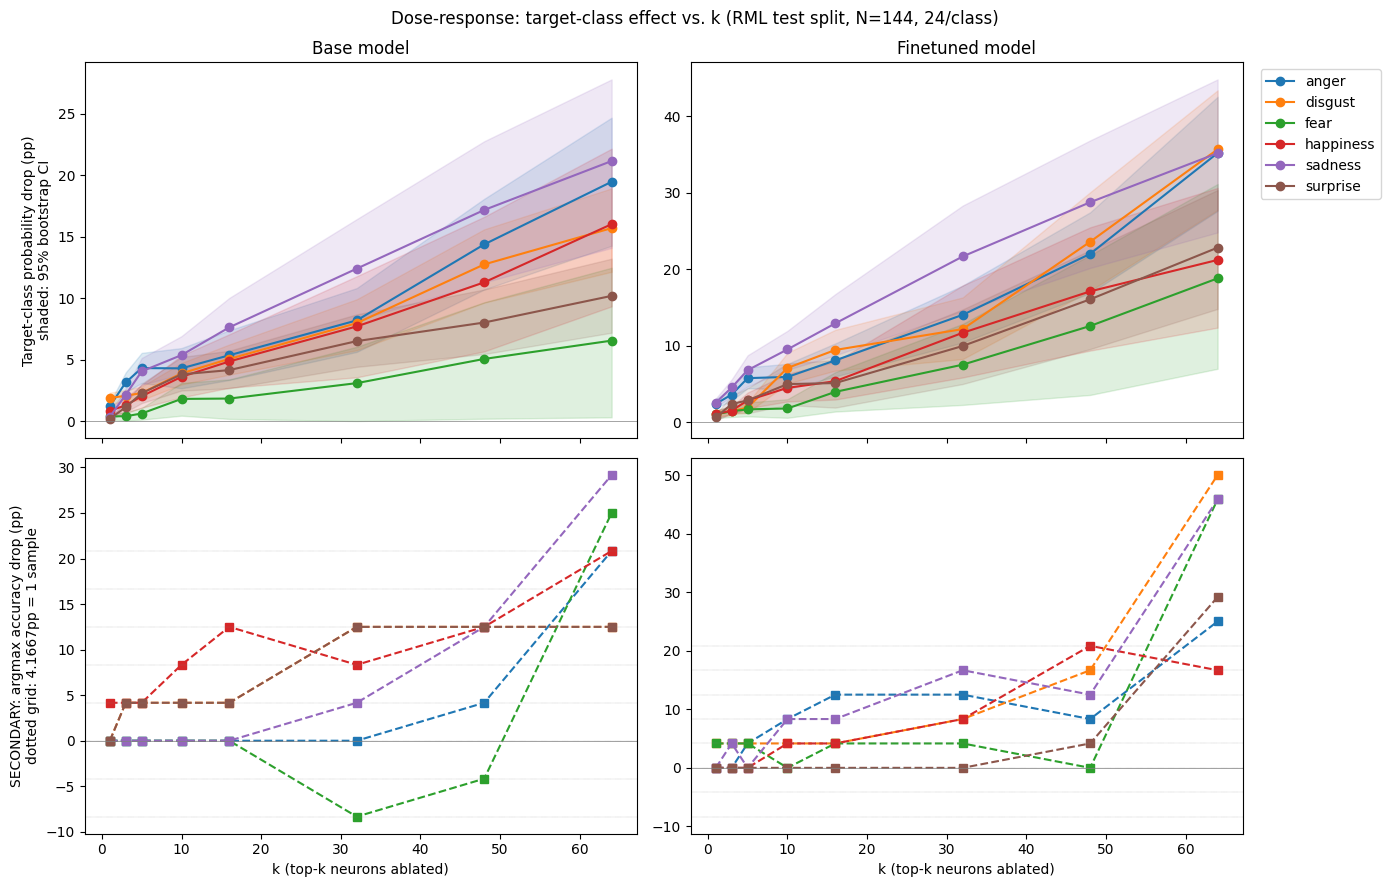


Week 4 Days 16-18 artifacts complete: Table VII/VIII/IX/X CSVs in results/, results/measurement_resolution.json, results/week3_random_ablation_null.json, results/week3_rank_validation.csv, dose-response figure in figures/. The written subsection is the manual step -- see Handoff.


In [18]:
# -- Week 4, Days 16-18: Export Tables VII/VIII/IX and the dose-response figure --
#
# Every exported table now carries the caveat columns next to the verdict it
# qualifies. The v3 run exported `causally_class_selective` and `outcome` while
# leaving `small_base_drop_flag` and the denominators behind in notebook stdout,
# so the CSVs read as findings even though the notebook had already printed that
# all six rows were single-sample noise. A verdict and the reason it might be
# void travel together or not at all.
import matplotlib.pyplot as plt

def build_table_vii_viii(model_name):
    rows = []
    for class_name in EMOTION_CLASSES:
        r = ablation_sweeps[model_name][class_name][5]
        t = r['target_effect']
        rows.append({
            'class': class_name,
            'top5_neurons': str(r['target_indices']),
            'n_target_samples': t['n'],
            'target_prob_drop_pp': t['prob_drop_pp'],
            'target_prob_drop_ci95_lo': t['prob_drop_ci95_lo'],
            'target_prob_drop_ci95_hi': t['prob_drop_ci95_hi'],
            'target_ci_excludes_zero': t['prob_drop_ci_excludes_zero'],
            'target_margin_drop': t['margin_drop'],
            'mean_non_target_prob_drop_pp': r['mean_non_target_prob_drop_pp'],
            'mean_abs_non_target_prob_drop_pp': r['mean_abs_non_target_prob_drop_pp'],
            'non_target_denom_ci95_lo': r['denominator_ci95_lo'],
            'non_target_denom_ci95_hi': r['denominator_ci95_hi'],
            'n_resolvable_non_target': r['n_resolvable_non_target'],
            'selectivity_ratio': r['selectivity_ratio'],
            'selectivity_undefined_reason': r['selectivity_undefined_reason'] or '',
            'causally_class_selective': r['causally_class_selective'],
            # Secondary, quantized to ACC_RESOLUTION_PP (4.1667pp = one utterance):
            'legacy_acc_target_drop_pp': r['legacy_acc_target_drop_pp'],
            'legacy_acc_mean_abs_non_target_drop_pp': r['legacy_acc_mean_abs_non_target_drop_pp'],
        })
    return pd.DataFrame(rows)

table_vii = build_table_vii_viii('base')       # Table VII: base model, k=5
table_viii = build_table_vii_viii('finetuned') # Table VIII: fine-tuned model, k=5
# Table IX now carries its own null and its own chance level. The substrate band column
# is gone (ADR 0006): it labelled every class 'Preservation' because both band schemes
# treat all of R > 1 as one bucket, and every observed R is above 1.
table_ix = retention_df[[
    'class', 'cosine_similarity', 'cosine_matched_minus_mismatched',
    'base_ft_top5_overlap', 'overlap_expected_by_chance', 'overlap_p_ge_observed',
    'base_drop_pp', 'ft_drop_pp', 'ft_ci_excludes_zero',
    'R', 'R_ci95_lo', 'R_ci95_hi',
    'R_null', 'R_null_ci95_lo', 'R_null_ci95_hi', 'R_exceeds_null',
    'verdict', 'legacy_acc_ft_drop_pp',
]].rename(columns={'ft_drop_pp': 'delta_prob_target_class_base_neurons_in_ft'})
# Table X: the probe ranking checked against measured single-dimension damage (Day 13b).
table_x = rank_validation_df[['model', 'class', 'probe_top5', 'measured_top5', 'overlap',
                              'probe_top5_drop_pp', 'measured_top5_drop_pp',
                              'probe_over_measured', 'spearman_rho_top16_union']]
table_x.to_csv(os.path.join(project_path, 'results', 'table_x_probe_rank_validation.csv'), index=False)

table_vii.to_csv(os.path.join(project_path, 'results', 'table_vii_base_ablation_k5.csv'), index=False)
table_viii.to_csv(os.path.join(project_path, 'results', 'table_viii_finetuned_ablation_k5.csv'), index=False)
table_ix.to_csv(os.path.join(project_path, 'results', 'table_ix_cosine_and_transfer.csv'), index=False)

_brief = ['class', 'top5_neurons', 'target_prob_drop_pp', 'target_prob_drop_ci95_lo',
          'target_prob_drop_ci95_hi', 'mean_abs_non_target_prob_drop_pp',
          'selectivity_ratio', 'causally_class_selective', 'legacy_acc_target_drop_pp']
print("=== Table VII (base model, k=5) ===")
print(table_vii[_brief].to_string(index=False))
print("\n=== Table VIII (fine-tuned model, k=5) ===")
print(table_viii[_brief].to_string(index=False))
print("\n=== Table IX (cosine similarity + ablation transfer vs. random-ablation null) ===")
print(table_ix.to_string(index=False))
print("\n=== Table X (probe ranking vs. measured single-neuron damage) ===")
print(table_x.to_string(index=False))

# Measurement-resolution stamp, written next to the tables so a later reader does not
# have to reconstruct why the primary column is a probability rather than an accuracy.
_resolution_note = {
    'eval_split': EVAL_SPLIT,
    'n_eval_samples': int(len(activations['base'][EVAL_SPLIT]['labels'])),
    'samples_per_class': SAMPLES_PER_CLASS,
    'argmax_accuracy_resolution_pp': ACC_RESOLUTION_PP,
    'primary_measure': 'mean true-class softmax probability drop (pp), paired '
                       'class-stratified bootstrap, 95% CI',
    'bootstrap_draws': BOOTSTRAP_DRAWS,
    'bootstrap_seed': BOOTSTRAP_SEED,
    'ratio_denominator_floor_pp': MIN_DENOM_PP,
    'ratio_denominator_rule': 'The selectivity denominator is used only when at least one '
                              'non-target class has an effect whose CI excludes zero AND '
                              'the mean absolute non-target effect clears the floor above. '
                              'Otherwise the ratio is NaN with a stated reason. No epsilon '
                              'is ever substituted for a denominator.',
    'selectivity_threshold': SELECTIVITY_THRESHOLD,
    'note': 'The floor is a chosen constant; the sweep cell prints the observed '
            'distribution of denominators against it so it can be calibrated on real data.',
    'transfer_null': {
        'n_random_subsets': RANDOM_NULL_SUBSETS,
        'k': K_TRANSFER,
        'seed': RANDOM_NULL_SEED,
        'estimator': 'ratio of mean fine-tuned drop to mean base drop over random '
                     'k-dimension subsets; CI by bootstrap over subsets',
    },
    'substrate_bands': 'WITHDRAWN (ADR 0006). Both CONTEXT.md and ADR 0001 band only '
                       'R <= 1 and collapse all of R > 1 into Preservation, which is the '
                       'region every class occupies. R is reported with its CI against the '
                       'random-ablation null instead.',
    'top5_overlap_null': f'Hypergeometric({int(N_DIMS)}, 5, 5); expected overlap '
                         f'{OVERLAP_EXPECTED:.4f}; an overlap of 1 has p=0.343.',
}
with open(os.path.join(project_path, 'results', 'measurement_resolution.json'), 'w') as f:
    json.dump(_resolution_note, f, indent=2, default=float)

# Dose-response figure. Top row: the primary continuous measure with its bootstrap CI.
# Bottom row: the argmax accuracy drop the earlier revision reported, drawn on its own
# 4.1667pp grid -- it is included precisely so the staircase is visible.
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
for col, model_name in enumerate(['base', 'finetuned']):
    ax_p, ax_a = axes[0, col], axes[1, col]
    for class_name in EMOTION_CLASSES:
        res = [ablation_sweeps[model_name][class_name][k] for k in K_VALUES]
        drops = [r['target_effect']['prob_drop_pp'] for r in res]
        los = [r['target_effect']['prob_drop_ci95_lo'] for r in res]
        his = [r['target_effect']['prob_drop_ci95_hi'] for r in res]
        line, = ax_p.plot(K_VALUES, drops, marker='o', label=class_name)
        ax_p.fill_between(K_VALUES, los, his, alpha=0.15, color=line.get_color())
        ax_a.plot(K_VALUES, [r['legacy_acc_target_drop_pp'] for r in res],
                  marker='s', linestyle='--', color=line.get_color(), label=class_name)
    ax_p.set_title(f'{model_name.title()} model')
    ax_p.axhline(0, color='gray', linewidth=0.5)
    ax_a.axhline(0, color='gray', linewidth=0.5)
    for step in range(-2, 6):
        ax_a.axhline(step * ACC_RESOLUTION_PP, color='gray', linewidth=0.3, linestyle=':')
    ax_a.set_xlabel('k (top-k neurons ablated)')
axes[0, 0].set_ylabel('Target-class probability drop (pp)\nshaded: 95% bootstrap CI')
axes[1, 0].set_ylabel(f'SECONDARY: argmax accuracy drop (pp)\ndotted grid: {ACC_RESOLUTION_PP:.4f}pp = 1 sample')
axes[0, 1].legend(bbox_to_anchor=(1.02, 1), loc='upper left')
fig.suptitle(f'Dose-response: target-class effect vs. k (RML {EVAL_SPLIT} split, '
             f'N={_resolution_note["n_eval_samples"]}, {SAMPLES_PER_CLASS}/class)')
fig.tight_layout()
fig_path = os.path.join(project_path, 'figures', 'dose_response_k_sweep.png')
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f"\nSaved {fig_path}")
plt.show()

print("\nWeek 4 Days 16-18 artifacts complete: Table VII/VIII/IX/X CSVs in results/, "
      "results/measurement_resolution.json, results/week3_random_ablation_null.json, "
      "results/week3_rank_validation.csv, dose-response figure in figures/. The written "
      "subsection is the manual step -- see Handoff.")

# Handoff

`results/` now contains: `day0_dominant_modality.json`, `measurement_resolution.json`, `week1_probe_auc.json`, `week2_fast_path_verification.json`, `week2_{base,finetuned}_ablation_sweep.json`, `week3_rank_validation.csv`, `week3_ablation_transfer.json`, `week3_random_ablation_null.json`, `week3_transfer_retention.csv`, `table_{vii,viii,ix}_*.csv`, `table_x_probe_rank_validation.csv`. `figures/` has `dose_response_k_sweep.png`. `checkpoints/activations/` holds the cached tensors and their provenance stamps (resumable — Days 1–2 skip re-extraction when the stamp matches; the stamp covers checkpoint hashes, split sizes and split-ID hashes, so it does **not** by itself certify which audio route built the cache — the Day 0 step 2 SHAP cross-check in that same cell is what does).

**Next steps — Week 4, Days 16–18 (manual write-up):**

1. Write the session journal following the 7-part schema in `journals/GUIDELINES.md`. Record the actual fidelity-gate accuracies, the Day 0 step 2 SHAP margins, whether the falsification pair passed, whether the fast path verified, the probe AUCs, and the Week 3 verdict.
2. Draft Section VI-D per protocol Days 16–18 as **two negative results**, not as a mechanism story:
   - The Week 2 ablation-selectivity result stands as causal validation, **scoped to RML only** — say so explicitly.
   - Week 3 transfer is at chance. `R_exceeds_null` is `False` for all 6 of 6 classes: every class's transfer ratio R is matched by the random-ablation null over 2000 random k=5 subsets (`week3_random_ablation_null.json`). fear's eye-catching R = 4.34 sits against R_null = 4.01. Report R with its CI **against the null**, never as a substrate band — ADR 0006 withdrew the bands.
   - Week 3 Day 13b (`table_x_probe_rank_validation.csv`) is the second negative result: the L1 probe's top-5 |weight| neurons under-damage the measured top-5 in **12 of 12** model×class pairs (`probe_over_measured` 0.16–0.73, all < 1), and Spearman rho over the top-16 union is **negative in 11 of 12**. Probe weight magnitude does not rank causal importance here and mildly anti-ranks it. This is a limitation of the probe-selection method, and it must be stated wherever the top-5 selection is described.
3. Do **not** write the preservation-vs-reassignment / shared-substrate explanation for RML's limited fine-tuning gain. That framing was withdrawn by `docs/adr/0006-week3-transfer-null-and-band-withdrawal.md` and this run refutes it. Update Limitation #1 to record the negative outcome, with the other five datasets as future work.
4. State the dominant-modality framing the way ADR 0005 records it: audio leads on **per-neuron** attribution, text leads on **aggregate** attribution mass because it has 16× the dimensions. Both are the same measurement. Do not write "two metrics disagree", and do not write "audio won a near-tie".
5. Every downstream statistic is a **mean true-class softmax probability drop in pp**, with paired class-stratified bootstrap CIs (2000 draws, seed 20260811, common random numbers). Argmax accuracy is retained only as `legacy_acc_*` columns and must not be used for inference: the 144-sample test split gives 24 samples per class, so per-class accuracy moves only in 4.1667 pp steps (`measurement_resolution.json`). Selectivity ratios are NaN with a stated reason whenever the denominator is not resolvable — no epsilon floor is ever substituted.

**Out of scope** per protocol: the other five datasets, the LIRIS-ACCEDE diffuse-activation diagnostic, any SAE dictionary (Days 19–20 optional stretch only), and cross-modality comparisons beyond the single dominant modality.
